### Multiple Testing

Thus far, this textbook has mostly focused on estimation and its close cousin, prediction. In this chapter, we instead focus on hypothesis testing, which is key to conducting inference. We remind the reader that inference was briefly discussed in Chapter 2.

While Section 13.1 provides a brief review of null hypotheses, p-values, test statistics, and other key ideas in hypothesis testing, this chapter assumes that the reader has had previous exposure to these topics. In particular, we will not focus on why or how to conduct a hypothesis test — a topic on which entire books can be (and have been) written! Instead, we will assume that the reader is interested in testing some particular set of null hypotheses, and has a specific plan in mind for how to conduct the tests and obtain p-values.

Much of the emphasis in classical statistics focuses on testing a single null hypothesis, such as $H_0$: the expected blood pressure of mice in the control group equals the expected blood pressure of mice in the treatment group. Of course, we would probably like to discover that there is a difference between the mean blood pressure in the two groups. But for reasons that will become clear, we construct a null hypothesis corresponding to no difference.

In contemporary settings, we are often faced with huge amounts of data, and consequently may wish to test a great many null hypotheses. For instance, rather than simply testing $H_0$, we might want to test $m$ null hypotheses, $H_{01},\ldots,H_{0m}$, where $H_{0j}$: the expected value of the $j$-th biomarker among mice in the control group equals the expected value of the $j$-th biomarker among mice in the treatment group. When conducting multiple testing, we need to be very careful about how we interpret the results, in order to avoid erroneously rejecting far too many null hypotheses.

This chapter discusses classical as well as more contemporary ways to conduct multiple testing in a big-data setting. In Section 13.2, we highlight the challenges associated with multiple testing. Classical solutions to these challenges are presented in Section 13.3, and more contemporary solutions in Sections 13.4 and 13.5.

In particular, Section 13.4 focuses on the false discovery rate. The notion of the false discovery rate dates back to the 1990s. It quickly rose in popularity in the early 2000s, when large-scale data sets began to come out of genomics. These datasets were unique not only because of their large size, but also because they were typically collected for exploratory purposes: researchers collected these datasets in order to test a huge number of null hypotheses, rather than just a very small number of pre-specified null hypotheses. Today, of course, huge datasets are collected without a pre-specified null hypothesis across virtually all fields. As we will see, the false discovery rate is perfectly suited for this modern-day reality.

This chapter naturally centers upon the classical statistical technique of p-values, used to quantify the results of hypothesis tests. At the time of writing of this book (2020), p-values have recently been the topic of extensive commentary in the social science research community, to the extent that some social science journals have gone so far as to ban the use of p-values altogether! We will simply comment that when properly understood and applied, p-values provide a powerful tool for drawing inferential conclusions from our data.



#### A Quick Review of Hypothesis Testing



Hypothesis tests provide a rigorous statistical framework for answering simple “yes-or-no” questions about data, such as the following:

1. Is the true coefficient $ \beta_j $ in a linear regression of $ Y $ onto $ X_1,\ldots,X_p $ equal to zero?
2. Is there a difference in the expected blood pressure of laboratory mice in the control group and laboratory mice in the treatment group?

In Section 13.1.1, we briefly review the steps involved in hypothesis testing. Section 13.1.2 discusses the different types of mistakes, or errors, that can occur in hypothesis testing.



##### Testing a Hypothesis

Conducting a hypothesis test typically proceeds in four steps. First, we define the null and alternative hypotheses. Next, we construct a test statistic that summarizes the strength of evidence against the null hypothesis. We then compute a p-value that quantifies the probability of having obtained a comparable or more extreme value of the test statistic under the null hypothesis. Finally, based on the p-value, we decide whether to reject the null hypothesis. We now briefly discuss each of these steps in turn.


Step 1: Define the Null and Alternative Hypotheses



In hypothesis testing, we divide the world into two possibilities: the null hypothesis and the alternative hypothesis. The null hypothesis, denoted $H_0$, is the default state of belief about the world. For instance, null hypotheses associated with the two questions posed earlier in this chapter are as follows:

1. The true coefficient $ \beta_j $ in a linear regression of $ Y $ onto $ X_1,\ldots,X_p $ equals zero.
2. There is no difference between the expected blood pressure of mice in the control and treatment groups.

The null hypothesis is boring by construction: it may well be true, but we might hope that our data will tell us otherwise.

The alternative hypothesis, denoted $H_a$, represents something different and unexpected: for instance, that there is a difference between the expected blood pressure of the mice in the two groups. Typically, the alternative hypothesis simply posits that the null hypothesis does not hold: if the null hypothesis states that there is no difference between A and B, then the alternative hypothesis states that there is a difference between A and B.

It is important to note that the treatment of $H_0$ and $H_a$ is asymmetric. $H_0$ is treated as the default state of the world, and we focus on using data to reject $H_0$. If we reject $H_0$, then this provides evidence in favor of $H_a$. We can think of rejecting $H_0$ as making a discovery about our data: namely, we are discovering that $H_0$ does not hold! By contrast, if we fail to reject $H_0$, then our findings are more nebulous: we will not know whether we failed to reject $H_0$ because our sample size was too small (in which case testing $H_0$ again on a larger or higher-quality dataset might lead to rejection), or whether we failed to reject $H_0$ because $H_0$ really holds.


Step 2: Construct the Test Statistic

Next, we wish to use our data in order to find evidence for or against the null hypothesis. In order to do this, we must compute a test statistic, denoted $T$, which summarizes the extent to which our data are consistent with $H_0$. The way in which we construct $T$ depends on the nature of the null hypothesis that we are testing.

To make things concrete, let $x_{t1},\ldots,x_{tn}$ denote the blood pressure measurements for the $n_t$ mice in the treatment group, and let $x_{c1},\ldots,x_{cn}$ denote the blood pressure measurements for the $n_c$ mice in the control group, and $\mu_t = E(X_t), \mu_c = E(X_c)$. To test $H_0 : \mu_t = \mu_c$, we make use of a two-sample t-statistic, defined as

$$
T = \frac{\hat{\mu}_t - \hat{\mu}_c}{s \sqrt{\frac{1}{n_t} + \frac{1}{n_c}}} \tag{13.1}
$$

where 

$$
\hat{\mu}_t = \frac{1}{n_t} \sum_{i=1}^{n_t} x_{t_i}, \quad \hat{\mu}_c = \frac{1}{n_c} \sum_{i=1}^{n_c} x_{c_i}, 
$$

and

$$
s = \frac{(n_t - 1)s^2_t + (n_c - 1)s^2_c}{n_t + n_c - 2} \tag{13.2}
$$

is an estimator of the pooled standard deviation of the two samples. Here, $s^2_t$ and $s^2_c$ are unbiased estimators of the variance of the blood pressure in the treatment and control groups, respectively. A large (absolute) value of $T$ provides evidence against $H_0 : \mu_t = \mu_c$, and hence evidence in support of $H_a : \mu_t \neq \mu_c$.


Step 3: Compute the p-Value

In the previous section, we noted that a large (absolute) value of a two sample t-statistic provides evidence against $H_0$. This begs the question: how large is large? In other words, how much evidence against $H_0$ is provided by a given value of the test statistic?

The notion of a p-value provides us with a way to formalize as well as answer this question. The p-value is defined as the probability of observing a test statistic equal to or more extreme than the observed statistic, under the assumption that $H_0$ is in fact true. Therefore, a small p-value provides evidence against $H_0$.

To make this concrete, suppose that $ T = 2.33 $ for the test statistic in (13.1). Then, we can ask: what is the probability of having observed such a large value of $ T $, if indeed $ H_0 $ holds? It turns out that under $ H_0 $, the distribution of $ T $ in (13.1) follows approximately a $ N(0,1) $ distribution — that is, a normal distribution with mean 0 and variance 1. This distribution is displayed in Figure 13.1. We see that the vast majority — 98% — of the $ N(0,1) $ distribution falls between -2.33 and 2.33. This means that under $ H_0 $, we would expect to see such a large value of $|T|$ only 2% of the time. Therefore, the p-value corresponding to $ T = 2.33 $ is 0.02.

The distribution of the test statistic under $ H_0 $ (also known as the test statistic’s null distribution) will depend on the details of what type of null hypothesis is being tested, and what type of test statistic is used. In general, most commonly-used test statistics follow a well-known statistical distribution under the null hypothesis — such as a normal distribution, a t-distribution, a $ \chi^2 $-distribution, or an F-distribution — provided that the sample size is sufficiently large and that some other assumptions hold. Typically, the R function that is used to compute a test statistic will make use of this null distribution in order to output a p-value. In Section 13.5, we will see an approach to estimate the null distribution of a test statistic using re-sampling; in many contemporary settings, this is a very attractive option, as it exploits the availability of fast computers in order to avoid having to make potentially problematic assumptions about the data.

The p-value is perhaps one of the most used and abused notions in all of statistics. In particular, it is sometimes said that the p-value is the probability that $ H_0 $ holds, i.e., that the null hypothesis is true. This is not correct! The one and only correct interpretation of the p-value is as the fraction of the time that we would expect to see such an extreme value of the test statistic if we repeated the experiment many times, provided $ H_0 $ holds.

In Step 2 we computed a test statistic, and noted that a large (absolute) value of the test statistic provides evidence against $ H_0 $. In Step 3 the test statistic was converted to a p-value, with small p-values providing evidence against $ H_0 $. What, then, did we accomplish by converting the test statistic from Step 2 into a p-value in Step 3? To answer this question, suppose a data analyst conducts a statistical test, and reports a test statistic of $ T = 17.3 $. Does this provide strong evidence against $ H_0 $? It’s impossible to know, without more information: in particular, we would need to know what value of the test statistic should be expected, under $ H_0 $? This is exactly what a p-value gives us. In other words, a p-value allows us to transform our test statistic, which is measured on some arbitrary and uninterpretable scale, into a number between 0 and 1 that can be more easily interpreted.




$$
\begin{array}{|c|c|c|}
\hline
\text{Decision} & H_0 \text{ (Truth)} & H_a \\
\hline
\text{Reject } H_0 & \text{Type I Error} & \text{Correct} \\
\hline
\text{Do Not Reject } H_0 & \text{Correct} & \text{Type II Error} \\
\hline
\end{array}
$$

**TABLE 13.1.** A summary of the possible scenarios associated with testing the null hypothesis $ H_0 $. Type I errors are also known as false positives, and Type II errors as false negatives.


Step 4: Decide Whether to Reject the Null Hypothesis



Once we have computed a p-value corresponding to $ H_0 $, it remains for us to decide whether or not to reject $ H_0 $. (We do not usually talk about “accepting” $ H_0 $: instead, we talk about “failing to reject” $ H_0 $.) A small p-value indicates that such a large value of the test statistic is unlikely to occur under $ H_0 $, and thereby provides evidence against $ H_0 $. If the p-value is sufficiently small, then we will want to reject $ H_0 $ (and, therefore, make a “discovery”). But how small is small enough to reject $ H_0 $?

It turns out that the answer to this question is very much in the eyes of the beholder, or more specifically, the data analyst. The smaller the p-value, the stronger the evidence against $ H_0 $. In some fields, it is typical to reject $ H_0 $ if the p-value is below 0.05; this means that, if $ H_0 $ holds, we would expect to see such a small p-value no more than 5% of the time. However, in other fields, a much higher burden of proof is required: for example, in some areas of physics, it is typical to reject $ H_0 $ only if the p-value is below $ 10^{-9} $!

In the example displayed in Figure 13.1, if we use a threshold of 0.05 as our cut-off for rejecting the null hypothesis, then we will reject the null. By contrast, if we use a threshold of 0.01, then we will fail to reject the null. These ideas are formalized in the next section.



##### Type I and Type II Errors



If the null hypothesis holds, then we say that it is a true null hypothesis; otherwise, it is a false null hypothesis. For instance, if we test $ H_0 : \mu_t = \mu_c $ as in Section 13.1.1, and there is indeed no difference in the population mean blood pressure for mice in the treatment group and mice in the control group, then $ H_0 $ is true; otherwise, it is false. Of course, we do not know a priori whether $ H_0 $ is true or whether it is false: this is why we need to conduct a hypothesis test!


Table 13.1 summarizes the possible scenarios associated with testing the null hypothesis $ H_0 $. Once the hypothesis test is performed, the row of the table is known (based on whether or not we have rejected $ H_0 $); however, it is impossible for us to know which column we are in. If we reject $ H_0 $ when $ H_0 $ is false (i.e., when $ H_a $ is true), or if we do not reject $ H_0 $ when it is true, then we arrived at the correct result. However, if we erroneously reject $ H_0 $ when $ H_0 $ is in fact true, then we have committed a Type I error. The Type I error rate is defined as the probability of making a Type I error given that $ H_0 $ holds, i.e., the probability of incorrectly rejecting $ H_0 $. Alternatively, if we do not reject $ H_0 $ when $ H_0 $ is in fact false, then we have committed a Type II error. The power of the hypothesis test is defined as the probability of not making a Type II error given that $ H_a $ holds, i.e., the probability of correctly rejecting $ H_0 $.

Ideally we would like both the Type I and Type II error rates to be small. But in practice, this is hard to achieve! There typically is a trade-off: we can make the Type I error small by only rejecting $ H_0 $ if we are quite sure that it doesn’t hold; however, this will result in an increase in the Type II error. Alternatively, we can make the Type II error small by rejecting $ H_0 $ in the presence of even modest evidence that it does not hold, but this will cause the Type I error to be large. In practice, we typically view Type I errors as more “serious” than Type II errors, because the former involves declaring a scientific finding that is not correct. Hence, when we perform hypothesis testing, we typically require a low Type I error rate — e.g., at most $ \alpha = 0.05 $ — while trying to make the Type II error small (or, equivalently, the power large).

It turns out that there is a direct correspondence between the p-value threshold that causes us to reject $ H_0 $, and the Type I error rate. By only rejecting $ H_0 $ when the p-value is below $ \alpha $, we ensure that the Type I error rate will be less than or equal to $ \alpha $.



#### The Challenge of Multiple Testing

In the previous section, we saw that rejecting $ H_0 $ if the p-value is below (say) 0.01 provides us with a simple way to control the Type I error for $ H_0 $ at level 0.01: if $ H_0 $ is true, then there is no more than a 1% probability that we will reject it. But now suppose that we wish to test $ m $ null hypotheses, $ H_{01}, \ldots, H_{0m} $. Will it do to simply reject all null hypotheses for which the corresponding p-value falls below (say) 0.01? Stated another way, if we reject all null hypotheses for which the p-value falls below 0.01, then how many Type I errors should we expect to make?

As a first step towards answering this question, consider a stockbroker who wishes to drum up new clients by convincing them of her trading This is the text:

A stockbroker tells 1,024 ($1,024 = 2^{10}$) potential new clients that she can correctly predict whether Apple’s stock price will increase or decrease for 10 days running. There are $2^{10}$ possibilities for how Apple’s stock price might change over the course of these 10 days. Therefore, she emails each client one of these $2^{10}$ possibilities. The vast majority of her potential clients will find that the stockbroker’s predictions are no better than chance (and many will find them to be even worse than chance). But a broken clock is right twice a day, and one of her potential clients will be really impressed to find that her predictions were correct for all 10 of the days! And so the stockbroker gains a new client.

What happened here? Does the stockbroker have any actual insight into whether Apple’s stock price will increase or decrease? No. How, then, did she manage to predict Apple’s stock price perfectly for 10 days running? The answer is that she made a lot of guesses, and one of them happened to be exactly right.

How does this relate to multiple testing? Suppose that we flip 1,024 fair coins ten times each. Then we would expect (on average) one coin to come up all tails. (There’s a $1/2^{10} = 1/1,024$ chance that any single coin will come up all tails. So if we flip 1,024 coins, then we expect one coin to come up all tails, on average.) If one of our coins comes up all tails, then we might therefore conclude that this particular coin is not fair. In fact, a standard hypothesis test for the null hypothesis that this particular coin is fair would lead to a p-value below 0.002! But it would be incorrect to conclude that the coin is not fair: in fact, the null hypothesis holds, and we just happen to have gotten ten tails in a row by chance.

These examples illustrate the main challenge of multiple testing: when testing a huge number of null hypotheses, we are bound to get some very small p-values by chance. If we make a decision about whether to reject each null hypothesis without accounting for the fact that we have performed a very large number of tests, then we may end up rejecting a great number of true null hypotheses — that is, making a large number of Type I errors.

How severe is the problem? Recall from the previous section that if we reject a single null hypothesis, $ H_0 $, if its p-value is less than, say, $\alpha = 0.01$, then there is a 1% chance of making a false rejection if $ H_0 $ is in fact true. Now what if we test $ m $ null hypotheses, $ H_{01}, \ldots, H_{0m} $, all of which are true? There’s a 1% chance of rejecting any individual null hypothesis; therefore, we expect to falsely reject approximately $0.01m$ null hypotheses. If $ m = 10,000 $, then that means that we expect to falsely reject 100 null hypotheses by chance! That is a lot of Type I errors.

The crux of the issue is as follows: rejecting a null hypothesis if the p-value is below $\alpha$ controls the probability of falsely rejecting that null hypothesis at level $\alpha$. However, if we do this for $ m $ null hypotheses, then the chance of falsely rejecting at least one of the $ m $ null hypotheses is quite a bit higher!

|                | $H_0$ is True | $H_0$ is False | Total     |
|----------------|------------------|------------------|-----------|
| Reject $H_0$ |       $V$      |        $S$     |    $R$  |
| Do Not Reject $H_0$ |       $U$      |        $W$     |  $m - R$ |
| Total          |      $m_0$     |       $m$      | $m_0$   |

TABLE 13.2. A summary of the results of testing $m$ null hypotheses. A given null hypothesis is either true or false, and a test of that null hypothesis can either reject or fail to reject it. In practice, the individual values of $V$, $S$, $U$, and $W$ are unknown. However, we do have access to $V + S = R$ and $U + W = m - R$, which are the numbers of null hypotheses rejected and not rejected, respectively. We will investigate this issue in greater detail, and pose a solution to it, in Section 13.3.

#### The Family-Wise Error Rate

In the following sections, we will discuss testing multiple hypotheses while controlling the probability of making at least one Type I error.


##### What is the Family-Wise Error Rate?

Recall that the Type I error rate is the probability of rejecting $H_0$ if $H_0$ is true. The family-wise error rate (FWER) generalizes this notion to the setting of $m$ null hypotheses, $H_{01}, \ldots, H_{0m}$, and is defined as the probability of making at least one Type I error. To state this idea more formally, consider Table 13.2, which summarizes the possible outcomes when performing $m$ hypothesis tests. Here, $V$ represents the number of Type I errors (also known as false positives or false discoveries), $S$ the number of true positives, $U$ the number of true negatives, and $W$ the number of Type II errors (also known as false negatives). Then the family-wise error rate is given by:

$$
FWER = Pr(V \geq 1) \tag{13.3}
$$

A strategy of rejecting any null hypothesis for which the p-value is below $\alpha$ (i.e., controlling the Type I error for each null hypothesis at level $\alpha$) leads to a FWER of

$$
FWER(\alpha) = 1 - Pr(V = 0)
= 1 - Pr(\text{do not falsely reject any null hypotheses})
= 1 - Pr\left(\bigcap_{j=1}^{m}{\text{do not falsely reject } H_{0j}}\right). \tag{13.4}
$$

Recall from basic probability that if two events $A$ and $B$ are independent, then $Pr(A \cap B) = Pr(A) \cdot Pr(B)$. Therefore, if we make the additional rather strong assumptions that the $m$ tests are independent and that all $m$ null hypotheses are true, then

$$
FWER(\alpha) = 1 - (1 - \alpha)^{m}. \tag{13.5}
$$


Hence, if we test only one null hypothesis, then 

$$
FWER(\alpha) = 1 - (1 - \alpha)^1 = \alpha,
$$

so the Type I error rate and the FWER are equal. However, if we perform $m = 100$ independent tests, then 

$$
FWER(\alpha) = 1 - (1 - \alpha)^{100}.
$$

For instance, taking $\alpha = 0.05$ leads to a FWER of 

$$
1 - (1 - 0.05)^{100} \approx 0.994.
$$

In other words, we are virtually guaranteed to make at least one Type I error! Figure 13.2 displays (13.5) for various values of $m$, the number of hypotheses, and $\alpha$, the Type I error. We see that setting $\alpha = 0.05$ results in a high FWER even for moderate $m$. With $\alpha = 0.01$, we can test no more than five null hypotheses before the FWER exceeds 0.05. Only for very small values, such as $\alpha = 0.001$, do we manage to ensure a small FWER, at least for moderately-sized $m$.

We now briefly return to the example in Section 13.1.1, in which we consider testing a single null hypothesis of the form $H_0 : \mu_t = \mu_c$ using a two-sample t-statistic. Recall from Figure 13.1 that in order to guarantee that the Type I error does not exceed 0.02, we decide whether or not to reject $H_0$ using a cutpoint of 2.33 (i.e., we reject $H_0$ if $|T| > 2.33$). Now, what if we wish to test 10 null hypotheses using two-sample t-statistics, instead of just one? We will see in Section 13.3.2 that we can guarantee that the FWER does not exceed 0.02 by rejecting only null hypotheses for which the p-value falls below 0.002. This corresponds to a much more stringent cutpoint of 3.09 (i.e., we should reject $H_{0j}$ only if its test statistic $|T_j| > 3.09$, for $j = 1, \ldots, 10$). In other words, controlling the FWER at level $\alpha$ amounts to a much higher bar, in terms of evidence required to reject any given null hypothesis, than simply controlling the Type I error for each null hypothesis at level $\alpha$.

$Manager$ | $Mean$, $\bar{x}$ | $Standard$ $Deviation$, $s$ | $t-statistic$ | $p-value$
--- | --- | --- | --- | ---
$One$ | 3.0 | 7.4 | 6.9 | 0.006
$Two$ | -0.1 | 7.5 | 2.86 | 0.918
$Three$ | 2.8 | 6.7 | 2.62 | 0.012
$Four$ | 0.5 | 6.8 | 0.53 | 0.601
$Five$ | 0.3 | 2.86 | 0.31 | 0.756

**TABLE 13.3.** The first two columns correspond to the sample mean and sample standard deviation of the percentage excess return, over $n = 50$ months, for the first five managers in the Fund dataset. The last two columns provide the t-statistic $(\frac{n \cdot \bar{X}}{S})$ and associated p-value for testing $H_{0j} : \mu_j = 0$, the null hypothesis that the (population) mean return for the $j$th hedge fund manager equals zero.


#### Approaches to Control the Family-Wise Error Rate

In this section, we briefly survey some approaches to control the FWER. We will illustrate these approaches on the Fund dataset, which records the monthly percentage excess returns for 2,000 fund managers over $n = 50$ months. Table 13.3 provides relevant summary statistics for the first five managers.

We first present the Bonferroni method and Holm’s step-down procedure, which are very general-purpose approaches for controlling the FWER that can be applied whenever $m$ p-values have been computed, regardless of the form of the null hypotheses, the choice of test statistics, or the (in)dependence of the p-values. We then briefly discuss Tukey’s method and Scheffé’s method in order to illustrate the fact that, in certain situations, more specialized approaches for controlling the FWER may be preferable.


The Bonferroni Method


As in the previous section, suppose we wish to test $H_{01}, \ldots, H_{0m}$. Let $A_j$ denote the event that we make a Type I error for the $j$th null hypothesis, for $j = 1, \ldots, m$. Then

$$
FWER = Pr(\text{falsely reject at least one null hypothesis}) = Pr\left(\bigcup_{j=1}^{m} A_j\right) \leq \sum_{j=1}^{m} Pr(A_j).
$$

In the above, the inequality results from the fact that for any two events $A$ and $B$, $Pr(A \cup B) \leq Pr(A) + Pr(B)$, regardless of whether $A$ and $B$ are independent. The Bonferroni method, or Bonferroni correction, sets the threshold for rejecting each hypothesis test to $\alpha/m$, so that $Pr(A_j) \leq \alpha/m$. Equation 13.6 implies that so this procedure controls the FWER at level $\alpha$. For instance, in order to control the FWER at level 0.1 while testing $m = 100$ null hypotheses, the Bonferroni procedure requires us to control the Type I error for each null hypothesis at level $0.1/100 = 0.001$, i.e. to reject all null hypotheses for which the p-value is below 0.001.

$$
FWER(\alpha/m) \leq m \cdot \frac{\alpha}{m} = \alpha.
$$

We now consider the Fund dataset in Table 13.3. If we control the Type I error at level $\alpha = 0.05$ for each fund manager separately, then we will conclude that the first and third managers have significantly non-zero excess returns; in other words, we will reject $H_{01} : \mu_1 = 0$ and $H_{03} : \mu_3 = 0$. However, as discussed in previous sections, this procedure does not account for the fact that we have tested multiple hypotheses, and therefore it will lead to a FWER greater than 0.05.

If we instead wish to control the FWER at level 0.05, then, using a Bonferroni correction, we must control the Type I error for each individual manager at level $\alpha/m = 0.05/5 = 0.01$. Consequently, we will reject the null hypothesis only for the first manager, since the p-values for all other managers exceed 0.01. The Bonferroni correction gives us peace of mind that we have not falsely rejected too many null hypotheses, but for a price: we reject few null hypotheses, and thus will typically make quite a few Type II errors.

The Bonferroni correction is by far the best-known and most commonly used multiplicity correction in all of statistics. Its ubiquity is due in large part to the fact that it is very easy to understand and simple to implement, and also from the fact that it successfully controls Type I error regardless of whether the $m$ hypothesis tests are independent. However, as we will see, it is typically neither the most powerful nor the best approach for multiple testing correction. In particular, the Bonferroni correction can be quite conservative, in the sense that the true FWER is often quite a bit lower than the nominal (or target) FWER; this results from the inequality in (13.6). By contrast, a less conservative procedure might allow us to control the FWER while rejecting more null hypotheses, and therefore making fewer Type II errors.


Holm’s Step-Down Procedure


Holm’s method, also known as Holm’s step-down procedure or the Holm–Bonferroni method, is an alternative to the Bonferroni procedure. Holm’s method controls the FWER, but it is less conservative than Bonferroni, in the sense that it will reject more null hypotheses, typically resulting in fewer Type II errors and hence greater power. The procedure is summarized in Algorithm 13.1. The proof that this method controls the FWER is similar to, but slightly more complicated than, the argument in (13.6) that the Bonferroni method controls the FWER. 

It is worth noting that in Holm’s procedure, the threshold that we use to reject each null hypothesis — $p_{(L)}$ in Step 5 — actually depends on the values of all $m$ of the p-values. (See the definition of $L$ in (13.7).) This is in contrast to the Bonferroni procedure, in which to control the FWER at level $\alpha$, we reject any null hypotheses for which the p-value is below $\alpha/m$, regardless of the other p-values. Holm’s method makes no independence assumptions about the $m$ hypothesis tests and is uniformly more powerful than the Bonferroni method — it will always rejects at least as many null hypotheses as Bonferroni — and so it should always be preferred.

**Algorithm 13.1** $\text{Holm’s Step-Down Procedure to Control the FWER}$

---
1. Specify $\alpha$, the level at which to control the FWER.
2. Compute p-values $p_1, \ldots, p_m$ for the $m$ null hypotheses $H_{01}, \ldots, H_{0m}$.
3. Order the p-values so that $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$.
4. Define
   $$
   L = \min \{ j : p_{(j)} > \frac{\alpha}{m + 1 - j} \}. \tag{13.7}
   $$
5. Reject all null hypotheses $H_{0j}$ for which $p_j < p_{(L)}$.
---

We now consider applying Holm’s method to the first five fund managers in the Fund dataset in Table 13.3, while controlling the FWER at level 0.05. The ordered p-values are $p_{(1)} = 0.006$, $p_{(2)} = 0.012$, $p_{(3)} = 0.601$, $p_{(4)} = 0.756$, and $p_{(5)} = 0.918$. The Holm procedure rejects the first two null hypotheses, because $p_{(1)} = 0.006 < 0.05/(5 + 1 - 1) = 0.01$ and $p_{(2)} = 0.012 < 0.05/(5 + 1 - 2) = 0.0125$, but $p_{(3)} = 0.601 > 0.05/(5 + 1 - 3) = 0.0167$, which implies that $L = 3$. We note that, in this setting, Holm is more powerful than Bonferroni: the former rejects the null hypotheses for the first and third managers, whereas the latter rejects the null hypothesis only for the first manager.

Figure 13.3 provides an illustration of the Bonferroni and Holm methods on three simulated data sets in a setting involving $m = 10$ hypothesis tests, of which $m_0 = 2$ of the null hypotheses are true. Each panel displays the ten corresponding p-values, ordered from smallest to largest, and plotted on a log scale. The eight red points represent the false null hypotheses, and the two black points represent the true null hypotheses. We wish to control the FWER at level 0.05. The Bonferroni procedure requires us to reject all null hypotheses for which the p-value is below 0.005; this is represented by the black horizontal line. The Holm procedure requires us to reject all null hypotheses that fall below the blue line. The blue line always lies above the black line, so Holm will always reject more tests than Bonferroni; the region between the two lines corresponds to the hypotheses that are only rejected by Holm. In the left-hand panel, both Bonferroni and Holm successfully reject seven of the eight false null hypotheses. In the center panel, Holm successfully rejects all eight of the false null hypotheses, while Bonferroni fails to reject one. In the right-hand panel, Bonferroni only rejects three of the false null hypotheses, while Holm rejects all eight. Neither Bonferroni nor Holm makes any Type I errors in these examples.


Two Special Cases: Tukey’s Method and Scheffé’s Method

Bonferroni’s method and Holm’s method can be used in virtually any setting in which we wish to control the FWER for $m$ null hypotheses: they make no assumptions about the nature of the null hypotheses, the type of test statistic used, or the (in)dependence of the p-values. However, in certain very specific settings, we can achieve higher power by controlling the FWER using approaches that are more tailored to the task at hand. Tukey’s method and Scheffé’s method provide two such examples.

Table 13.3 indicates that for the Fund dataset, Managers One and Two have the greatest difference in their sample mean returns. This finding might motivate us to test the null hypothesis $H_0 : \mu_1 = \mu_2$, where $\mu_j$ is the (population) mean return for the $j$th fund manager. A two-sample t-test (13.1) for $H_0$ yields a p-value of 0.0349, suggesting modest evidence against $H_0$. However, this p-value is misleading, since we decided to compare the average returns of Managers One and Two only after having examined the returns for all five managers; this essentially amounts to having performed $m = 5$ $(5 - 1)/2 = 10$ hypothesis tests, and selecting the one with the smallest p-value. This suggests that in order to control the FWER at level 0.05, we should make a Bonferroni correction for $m = 10$ hypothesis tests, and therefore should only reject a null hypothesis for which the p-value is below 0.005. If we do this, then we will be unable to reject the null hypothesis that Managers One and Two have identical performance.

However, in this setting, a Bonferroni correction is actually a bit too stringent, since it fails to consider the fact that the $m = 10$ hypothesis tests are all somewhat related: for instance, Managers Two and Five have similar mean returns, as do Managers Two and Four; this guarantees that the mean returns of Managers Four and Five are similar. Stated another way, the $m$ p-values for the $m$ pairwise comparisons are not independent. Therefore, it should be possible to control the FWER in a way that is less conservative. This is exactly the idea behind Tukey’s method: when Tukey’s performing $m = G(G - 1)/2$ pairwise comparisons of $G$ means, it allows us to control the FWER at level $\alpha$ while rejecting all null hypotheses for which the p-value falls below $T$, for some $T > \alpha/m$.

Figure 13.4 illustrates Tukey’s method on three simulated data sets in a setting with $G = 6$ means, with $\mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5 = \mu_6$. Therefore, of the $m = G(G - 1)/2 = 15$ null hypotheses of the form $H_0 : \mu_j = \mu_k$, ten are true and five are false. In each panel, the true null hypotheses are displayed in black, and the false ones are in red. The horizontal lines indicate that Tukey’s method always results in at least as many rejections as Bonferroni’s method. In the left-hand panel, Tukey correctly rejects two more null hypotheses than Bonferroni.

Now, suppose that we once again examine the data in Table 13.3, and notice that Managers One and Three have higher mean returns than Managers Two, Four, and Five. This might motivate us to test the null hypothesis 

$$
H_0 : \frac{1}{2} (\mu_1 + \mu_3) = \frac{1}{3} (\mu_2 + \mu_4 + \mu_5).
$$

(Recall that $\mu_j$ is the population mean return for the $\text{jth}$ hedge fund manager.) It turns out that we could test (13.8) using a variant of the two sample t-test presented in (13.1), leading to a p-value of 0.004. This suggests strong evidence of a difference between Managers One and Three compared to Managers Two, Four, and Five. However, there is a problem: we decided to test the null hypothesis in (13.8) only after peeking at the data in Table 13.3. In a sense, this means that we have conducted multiple testing. In this setting, using Bonferroni to control the FWER at level $\alpha$ would require a p-value threshold of $\alpha/m$, for an extremely large value of $m^{14}$.

Scheffé’s method is designed for exactly this setting. It allows us to compute a value $S$ such that rejecting the null hypothesis $H_0$ in (13.8) if the p-value is below $S$ will control the Type I error at level $\alpha$. It turns out that for the Fund example, in order to control the Type I error at level $\alpha = 0.05$, we must set $S = 0.002$. Therefore, we are unable to reject $H_0$ in (13.8), despite the apparently very small p-value of 0.004. An important advantage of Scheffé’s method is that we can use this same threshold of $S = 0.002$ in order to perform a pairwise comparison of any split of the managers into two groups: for instance, we could also test 

$$
H_0 : \frac{1}{3} (\mu_1 + \mu_2 + \mu_3) = \frac{1}{2} (\mu_4 + \mu_5)
$$

and 

$$
H_0 : \frac{1}{4} (\mu_1 + \mu_2 + \mu_3 + \mu_4) = \mu_5
$$

using the same threshold of 0.002, without needing to further adjust for multiple testing.

To summarize, Holm’s procedure and Bonferroni’s procedure are very general approaches for multiple testing correction that can be applied under all circumstances. However, in certain special cases, more powerful procedures for multiple testing correction may be available, in order to control the FWER while achieving higher power (i.e., committing fewer Type II errors) than would be possible using Holm or Bonferroni. In this section, we have illustrated two such examples.



##### Trade-Off Between the FWER and Power



In general, there is a trade-off between the FWER threshold that we choose, and our power to reject the null hypotheses. Recall that power is defined as the number of false null hypotheses that we reject divided by the total number of false null hypotheses, i.e., $S/(m - m_0)$ using the notation of Table 13.2. Figure 13.5 illustrates the results of a simulation setting involving $m$ null hypotheses, of which 90% are true and the remaining 10% are false; power is displayed as a function of the FWER. In this particular simulation setting, when $m = 10$, a FWER of 0.05 corresponds to power of approximately 60%. However, as $m$ increases, the power decreases. With $m = 500$, the power is below 0.2 at a FWER of 0.05, so that we successfully reject only 20% of the false null hypotheses.

Figure 13.5 indicates that it is reasonable to control the FWER when $m$ takes on a small value, like 5 or 10. However, for $m = 100$ or $m = 1,000$, attempting to control the FWER will make it almost impossible to reject any of the false null hypotheses. In other words, the power will be extremely low.

Why is this the case? Recall that, using the notation in Table 13.2, the FWER is defined as $\text{Pr}(V \geq 1)$ (13.3). In other words, controlling the FWER at level $\alpha$ guarantees that the data analyst is very unlikely (with probability no more than $\alpha$) to reject any true null hypotheses, i.e., to have any false positives. In order to make good on this guarantee when $m$ is large, the data analyst may be forced to reject very few null hypotheses, or perhaps even none at all (since if $R = 0$ then also $V = 0$; see Table 13.2).

This is the text:

This is scientifically uninteresting, and typically results in very low power, as in Figure 13.5.

In practice, when $m$ is large, we may be willing to tolerate a few false positives, in the interest of making more discoveries, i.e., more rejections of the null hypothesis. This is the motivation behind the false discovery rate, which we present next.



#### The False Discovery Rate



##### Intuition for the False Discovery Rate

As we just discussed, when $m$ is large, then trying to prevent any false positives (as in FWER control) is simply too stringent. Instead, we might try to make sure that the ratio of false positives ($V$) to total positives ($V + S = R$) is sufficiently low, so that most of the rejected null hypotheses are not false positives. The ratio $V/R$ is known as the false discovery proportion (FDP).

It might be tempting to ask the data analyst to control the FDP: to make sure that no more than, say, 20% of the rejected null hypotheses are false positives. However, in practice, controlling the FDP is an impossible task for the data analyst, since she has no way to be certain, on any particular dataset, which hypotheses are true and which are false. This is very similar to the fact that the data analyst can control the FWER, i.e., she can guarantee that $\text{Pr}(V \geq 1)$ for any pre-specified $\alpha$, but she cannot guarantee that $V = 0$ on any particular dataset (short of failing to reject any null hypotheses, i.e., setting $R = 0$).
 
Therefore, we instead control the false discovery rate (FDR)^{15}, defined as 

$$
\text{FDR} = \mathbb{E}(\text{FDP}) = \mathbb{E}(V/R).
$$

(13.9)  
When we control the FDR at (say) level $q = 20\%$, we are rejecting as many null hypotheses as possible while guaranteeing that no more than 20% of those rejected null hypotheses are false positives, on average.  

In the definition of the FDR in (13.9), the expectation is taken over the population from which the data are generated. For instance, suppose we control the FDR for $m$ null hypotheses at $q = 0.2$. This means that if we repeat this experiment a huge number of times, and each time control the FDR at $q = 0.2$, then we should expect that, on average, 20% of the rejected null hypotheses will be false positives. On a given dataset, the fraction of false positives among the rejected hypotheses may be greater than or less than 20%.  

Thus far, we have motivated the use of the FDR from a pragmatic perspective, by arguing that when $m$ is large, controlling the FWER is simply too stringent, and will not lead to “enough” discoveries. An additional motivation for the use of the FDR is that it aligns well with the way that data are often collected in contemporary applications. As datasets continue to grow in size across a variety of fields, it is increasingly common to conduct a huge number of hypothesis tests for exploratory, rather than confirmatory, purposes. For instance, a genomic researcher might sequence the genomes of individuals with and without some particular medical condition, and then, for each of 20,000 genes, test whether sequence variants in that gene are associated with the medical condition of interest. This amounts to performing $m = 20,000$ hypothesis tests. The analysis is exploratory in nature, in the sense that the researcher does not have any particular hypothesis in mind; instead, she wishes to see whether there is modest evidence for the association between each gene and the disease, with a plan to further investigate any genes for which there is such evidence. She is likely willing to tolerate some number of false positives in the set of genes that she will investigate further; thus, the FWER is not an appropriate choice. However, some correction for multiple testing is required: it would not be a good idea for her to simply investigate all genes with p-values less than (say) 0.05, since we would expect 1,000 genes to have such small p-values simply by chance, even if no genes are associated with the disease (since $0.05 \times 20,000 = 1,000$). Controlling the FDR for her exploratory analysis at 20% guarantees that — on average — no more than 20% of the genes that she investigates further are false positives.

It is worth noting that unlike p-values, for which a threshold of 0.05 is typically viewed as the minimum standard of evidence for a “positive” result, and a threshold of 0.01 or even 0.001 is viewed as much more compelling, there is no standard accepted threshold for FDR control. Instead, the choice of FDR threshold is typically context-dependent, or even dataset dependent. For instance, the genomic researcher in the previous example might seek to control the FDR at a threshold of 10% if the planned follow up analysis is time-consuming or expensive. Alternatively, a much larger threshold of 30% might be suitable if she plans an inexpensive follow-up analysis.


##### The Benjamini–Hochberg Procedure

We now focus on the task of controlling the FDR: that is, deciding which null hypotheses to reject while guaranteeing that the FDR, $\mathbb{E}(V/R)$, is less than or equal to some pre-specified value $q$. In order to do this, we need some way to connect the p-values, $p_1, \ldots, p_m$, from the $m$ null hypotheses to the desired FDR value, $q$. It turns out that a very simple procedure, outlined in Algorithm 13.2, can be used to control the FDR.

**Algorithm 13.2** $\text{Benjamini–Hochberg Procedure to Control the FDR}$

---

1. Specify $q$, the level at which to control the FDR.
2. Compute p-values, $p_1, \ldots, p_m$, for the $m$ null hypotheses $H_{0_1}, \ldots, H_{0_m}$.
3. Order the $m$ p-values so that $p_{(1)} < p_{(2)} < \ldots < p_{(m)}$.
4. Define 

$$
L = \max\{j : p_{(j)} < \frac{qj}{m}\}. \tag{13.10}
$$

5. Reject all null hypotheses $H_{0_j}$ for which $p_j \leq p_{(L)}$.

---

Algorithm 13.2 is known as the Benjamini–Hochberg procedure. The crux of this procedure lies in (13.10). For example, consider again the first five managers in the Fund dataset, presented in Table 13.3. (In this example, $m=5$, although typically we control the FDR in settings involving a much greater number of null hypotheses.) We see that $p_{(1)} = 0.006 < 0.05 \cdot 1/5$, $p_{(2)} = 0.012 < 0.05 \cdot 2/5$, $p_{(3)} = 0.601 > 0.05 \cdot 3/5$, $p_{(4)} = 0.756 > 0.05 \cdot 4/5$, and $p_{(5)} = 0.918 > 0.05 \cdot 5/5$. Therefore, to control the FDR at 5%, we reject the null hypotheses that the first and second fund managers perform no better than chance.

As long as the $m$ p-values are independent or only mildly dependent, then the Benjamini–Hochberg procedure guarantees that

$$
\text{FDR} \leq q.
$$

In other words, this procedure ensures that, on average, no more than a fraction $q$ of the rejected null hypotheses are false positives. Remarkably, this holds regardless of how many null hypotheses are true and regardless of the distribution of the p-values for the null hypotheses that are false. Therefore, the Benjamini–Hochberg procedure gives us a very easy way to determine, given a set of $m$ p-values, which null hypotheses to reject in order to control the FDR at any pre-specified level $q$.

There is a fundamental difference between the Bonferroni procedure of Section 13.3.2 and the Benjamini–Hochberg procedure. In the Bonferroni procedure, in order to control the FWER for $m$ null hypotheses at level $\alpha$, we must simply reject null hypotheses for which the p-value is below $\alpha/m$. This threshold of $\alpha/m$ does not depend on anything about the data (beyond the value of $m$), and certainly does not depend on the p-values themselves. By contrast, the rejection threshold used in the Benjamini–Hochberg procedure is more complicated: we reject all null hypotheses for which the p-value is less than or equal to the $L$th smallest p-value, where $L$ is itself a function of all $m$ p-values, as in (13.10). Therefore, when conducting the Benjamini–Hochberg procedure, we cannot plan out in advance what threshold we will use to reject p-values; we need to first see our data. For instance, in the abstract, there is no way to know whether we will reject a null hypothesis corresponding to a p-value of 0.01 when using an FDR threshold of 0.1 with $m = 100$; the answer depends on the values of the other $m - 1$ p-values. This property of the Benjamini–Hochberg procedure is shared by the Holm procedure, which also involves a data-dependent p-value threshold.

Figure 13.6 displays the results of applying the Bonferroni and Benjamini–Hochberg procedures on the Fund dataset, using the full set of $m = 2,000$ fund managers, of which the first five were displayed in Table 13.3. When the FWER is controlled at level 0.3 using Bonferroni, only one null hypothesis is rejected; that is, we can conclude only that a single fund manager is beating the market. This is despite the fact that a substantial portion of the $m = 2,000$ fund managers appear to have beaten the market without performing correction for multiple testing — for instance, 13 of them have p-values below 0.001. By contrast, when the FDR is controlled at level 0.3, we can conclude that 279 fund managers are beating the market: we expect that no more than around $279 \times 0.3 = 83.7$ of these fund managers had good performance only due to chance. Thus, we see that FDR control is much milder — and more powerful — than FWER control, in the sense that it allows us to reject many more null hypotheses, with a cost of substantially more false positives.

The Benjamini–Hochberg procedure has been around since the mid 1990s. While a great many papers have been published since then proposing alternative approaches for FDR control that can perform better in particular scenarios, the Benjamini–Hochberg procedure remains a very useful and widely-applicable approach.



#### A Re-Sampling Approach to p-Values and False Discovery Rates



Thus far, the discussion in this chapter has assumed that we are interested in testing a particular null hypothesis $H_0$ using a test statistic $T$, which has some known (or assumed) distribution under $H_0$, such as a normal distribution, a t-distribution, a $\chi^2$-distribution, or an F-distribution. This is referred to as the theoretical null distribution. We typically rely upon the availability of a theoretical null distribution in order to obtain a p-value associated with our test statistic. Indeed, for most of the types of null hypotheses that we might be interested in testing, a theoretical null distribution is available, provided that we are willing to make stringent assumptions about our data.

However, if our null hypothesis $H_0$ or test statistic $T$ is somewhat unusual, then it may be the case that no theoretical null distribution is available. Alternatively, even if a theoretical null distribution exists, then we may be wary of relying upon it, perhaps because some assumption that is required for it to hold is violated. For instance, maybe the sample size is too small.

In this section, we present a framework for performing inference in this setting, which exploits the availability of fast computers in order to approximate the null distribution of $T$, and thereby to obtain a p-value. While this framework is very general, it must be carefully instantiated for a specific problem of interest. Therefore, in what follows, we consider a specific example in which we wish to test whether the means of two random variables are equal, using a two-sample t-test.

The discussion in this section is more challenging than the preceding sections in this chapter, and can be safely skipped by a reader who is content to use the theoretical null distribution to compute p-values for his or her test statistics.

##### A Re-Sampling Approach to the p-Value

We return to the example of Section 13.1.1, in which we wish to test whether the mean of a random variable $X$ equals the mean of a random variable $Y$, i.e. $H_0 : E(X) = E(Y)$, against the alternative $H_a : E(X) \neq E(Y)$. Given $n_X$ independent observations from $X$ and $n_Y$ independent observations from $Y$, the two-sample t-statistic takes the form

$$
T = \frac{\hat{\mu}_X - \hat{\mu}_Y}{s \sqrt{\frac{1}{n_X} + \frac{1}{n_Y}}}
$$

where $\hat{\mu}_X = \frac{1}{n_X} \sum_{i=1}^{n_X} x_i$, $\hat{\mu}_Y = \frac{1}{n_Y} \sum_{i=1}^{n_Y} y_i$, 

$$
s = \sqrt{\frac{(n_X - 1)s^2_X + (n_Y - 1)s^2_Y}{n_X + n_Y - 2}},
$$

and $s^2_X$ and $s^2_Y$ are unbiased estimators of the variances in the two groups. A large (absolute) value of $T$ provides evidence against $H_0$.

If $n_X$ and $n_Y$ are large, then $T$ in (13.11) approximately follows a $N(0,1)$ distribution. But if $n_X$ and $n_Y$ are small, then in the absence of a strong assumption about the distribution of $X$ and $Y$, we do not know the theoretical null distribution of $T$. In this case, it turns out that we can approximate the null distribution of $T$ using a re-sampling approach, or more specifically, a permutation approach.

To do this, we conduct a thought experiment. If $H_0$ holds, so that $E(X) = E(Y)$, and we make the stronger assumption that the distributions of $X$ and $Y$ are the same, then the distribution of $T$ is invariant under swapping observations of $X$ with observations of $Y$. That is, if we randomly swap some of the observations in $X$ with the observations in $Y$, then the test statistic $T$ computed based on this swapped data has the same distribution as $T$ based on the original data. This is true only if $H_0$ holds, and the distributions of $X$ and $Y$ are the same.

This suggests that in order to approximate the null distribution of $T$, we can take the following approach. We randomly permute the $n_X + n_Y$ observations $B$ times, for some large value of $B$, and each time compute (13.11). We let $T_1, \ldots, T_B$ denote the values of (13.11) on the permuted data. These can be viewed as an approximation of the null distribution of $T$ under $H_0$. Recall that by definition, a p-value is the probability of observing a test statistic at least this extreme under $H_0$. Therefore, to compute a p-value for $T$, we can simply compute

$$
\text{p-value} = \frac{1}{B} \sum_{b=1}^{B} 1\left( |T_b| \geq |T| \right),
$$

the fraction of permuted datasets for which the value of the test statistic is at least as extreme as the value observed on the original data. This procedure is summarized in Algorithm 13.3.

**Algorithm 13.3** $\text{Re-Sampling p-Value for a Two-Sample t-Test}$

---
1. Compute $T$, defined in (13.11), on the original data $x_1, \ldots, x_{n_X}$ and $y_1, \ldots, y_{n_Y}$.
2. For $b = 1, \ldots, B$, where $B$ is a large number (e.g. $B = 10,000$):
   (a) Permute the $n_X + n_Y$ observations at random. Call the first $n_X$ permuted observations $x_1, \ldots, x_{n_X}$, and call the remaining $n_Y$ observations $y_1, \ldots, y_{n_Y}$.
   (b) Compute (13.11) on the permuted data $x_1, \ldots, x_{n_X}$ and $y_1, \ldots, y_{n_Y}$, and call the result $T_b$.
3. The p-value is given by

$$
\text{p-value} = \frac{1}{B} \sum_{b=1}^{B} 1\left( |T_b| \geq |T| \right).
$$

---

We try out this procedure on the Khan dataset, which consists of expression measurements for 2,308 genes in four sub-types of small round blood cell tumors, a type of cancer typically seen in children. This dataset is part of the ISLR2 package. We restrict our attention to the two sub-types for which the most observations are available: rhabdomyosarcoma ($n_X = 29$) and Burkitt’s lymphoma ($n_Y = 25$).

A two-sample t-test for the null hypothesis that the 11th gene’s mean expression values are equal in the two groups yields $T = 2.09$. Using the theoretical null distribution, which is a $t_{52}$ distribution (since $n_X + n_Y - 2 = 52$), we obtain a p-value of 0.041. (Note that a $t_{52}$ distribution is virtually indistinguishable from a $N(0,1)$ distribution.) If we instead apply Algorithm 13.3 with $B = 10,000$, then we obtain a p-value of 0.042. Figure 13.7 displays the theoretical null distribution, the re-sampling null distribution, and the actual value of the test statistic ($T = 2.09$) for this gene. In this example, we see very little difference between the p-values obtained using the theoretical null distribution and the re-sampling null distribution.

By contrast, Figure 13.8 shows an analogous set of results for the 877th gene. In this case, there is a substantial difference between the theoretical and re-sampling null distributions, which results in a difference between their p-values.

In general, in settings with a smaller sample size or a more skewed data distribution (so that the theoretical null distribution is less accurate), the difference between the re-sampling and theoretical p-values will tend to be more pronounced. In fact, the substantial difference between the re-sampling and theoretical null distributions in Figure 13.8 is due to the fact that a single observation in the 877th gene is very far from the other observations, leading to a very skewed distribution.



##### A Re-Sampling Approach to the False Discovery Rate

Now, suppose that we wish to control the FDR for $m$ null hypotheses, $H_{01}, \ldots, H_{0m}$, in a setting in which either no theoretical null distribution is available, or else we simply prefer to avoid the use of a theoretical null distribution. As in Section 13.5.1, we make use of a two-sample t-statistic for each hypothesis, leading to the test statistics $T_1, \ldots, T_m$. We could simply compute a p-value for each of the $m$ null hypotheses, as in Section 13.5.1, and then apply the Benjamini–Hochberg procedure of Section 13.4.2 to these p-values. However, it turns out that we can do this in a more direct way, without even needing to compute p-values.

Recall from Section 13.4 that the FDR is defined as $E(V/R)$, using the notation in Table 13.2. In order to estimate the FDR via re-sampling, we first make the following approximation:

$$
\text{FDR} \approx \frac{E(V)}{R}. \tag{13.13}
$$

Now suppose we reject any null hypothesis for which the test statistic exceeds $c$ in absolute value. Then computing $R$ in the denominator on the right-hand side of (13.13) is straightforward: 

$$
R = \sum_{j=1}^{m} 1(|T_j| \geq c).
$$

However, the numerator $E(V)$ on the right-hand side of (13.13) is more challenging. This is the expected number of false positives associated with rejecting any null hypothesis for which the test statistic exceeds $c$ in absolute value. At the risk of stating the obvious, estimating $V$ is challenging because we do not know which of $H_{01}, \ldots, H_{0m}$ are really true, and so we do not know which rejected hypotheses are false positives. To overcome this problem, we take a re-sampling approach, in which we simulate data under $H_{01}, \ldots, H_{0m}$, and then compute the resulting test statistics. The number of re-sampled test statistics that exceed $c$ provides an estimate of $V$.

In greater detail, in the case of a two-sample t-statistic (13.11) for each of the null hypotheses $H_{01}, \ldots, H_{0m}$, we can estimate $E(V)$ as follows. Let $x^{(j)}_1, \ldots, x^{(j)}_{n_X}$ and $y^{(j)}_1, \ldots, y^{(j)}_{n_Y}$ denote the data associated with the $j$-th null hypothesis, $j = 1, \ldots, m$. We permute these $n_X + n_Y$ observations at random, and then compute the t-statistic on the permuted data. For this permuted data, we know that all of the null hypotheses $H_{01}, \ldots, H_{0m}$ hold; therefore, the number of permuted t-statistics that exceed the threshold $c$ in absolute value provides an estimate for $E(V)$. This estimate can be further improved by repeating the permutation process $B$ times, for a large value of $B$, and averaging the results.

Algorithm 13.4 details this procedure. It provides what is known as a plug-in estimate of the FDR, because the approximation in (13.13) allows us to estimate the FDR by plugging $R$ into the denominator and an estimate for $E(V)$ into the numerator.

We apply the re-sampling approach to the FDR from Algorithm 13.4, as well as the Benjamini–Hochberg approach from Algorithm 13.2 using theoretical p-values, to the $m = 2,308$ genes in the Khan dataset. Results are shown in Figure 13.9. We see that for a given number of rejected hypotheses, the estimated FDRs are almost identical for the two methods.

We began this section by noting that in order to control the FDR for $m$ hypothesis tests using a re-sampling approach, we could simply compute $m$ re-sampling p-values as in Section 13.5.1, and then apply the Benjamini–Hochberg procedure of Section 13.4.2 to these p-values. It turns out that if we define the $j$-th re-sampling p-value as

$$
p_j = \frac{1}{B} \sum_{b=1}^{B} 1(|T^{(b)}_j| \geq |T_j|), \tag{13.14}
$$

for $j = 1, \ldots, m$, instead of as in (13.12), then applying the Benjamini–Hochberg procedure to these re-sampled p-values is exactly equivalent to Algorithm 13.4. Note that (13.14) is an alternative to (13.12) that pools the information across all $m$ hypothesis tests in approximating the null distribution.



##### When Are Re-Sampling Approaches Useful?


In Sections 13.5.1 and 13.5.2, we considered testing null hypotheses of the form $H_0 : E(X) = E(Y)$ using a two-sample t-statistic (13.11), for which we approximated the null distribution via a re-sampling approach. We saw that using the re-sampling approach gave us substantially different results from using the theoretical p-value approach in Figure 13.8, but not in Figure 13.7.


**Algorithm 13.4** $\text{Plug-In FDR for a Two-Sample T-Test}$

---
1. Select a threshold $c$, where $c > 0$.
2. For $j = 1, \ldots, m$:
   a. Compute $T^{(j)}$, the two-sample t-statistic (13.11) for the null hypothesis $H_{0j}$ on the basis of the original data, $x^{(j)}_1, \ldots, x^{(j)}_{n_X}$ and $y^{(j)}_1, \ldots, y^{(j)}_{n_Y}$.
   b. For $b = 1, \ldots, B$, where $B$ is a large number (e.g. $B = 10,000$):
      i. Permute the $n_X + n_Y$ observations at random. Call the first $n_X$ observations $x^{(j)}_1, \ldots, x^{(j)}_{n_X}$, and call the remaining observations $y^{(j)}_1, \ldots, y^{(j)}_{n_Y}$.
      ii. Compute (13.11) on the permuted data $x^{(j)}_1, \ldots, x^{(j)}_{n_X}$ and $y^{(j)}_1, \ldots, y^{(j)}_{n_Y}$, and call the result $T^{(j)}_{,b}$.
3. Compute 
$$
R = \frac{1}{B} \sum_{j=1}^{m} 1(|T^{(j)}| \geq c).
$$
4. Compute 
$$
V = \frac{1}{B} \sum_{j=1}^{m} 1(|T^{(j)}_{,b}| \geq c).
$$
5. The estimated FDR associated with the threshold $c$ is $V/R$.
---



In general, there are two settings in which a re-sampling approach is particularly useful:

1. Perhaps no theoretical null distribution is available. This may be the case if you are testing an unusual null hypothesis $H_0$, or using an unusual test statistic $T$.
2. Perhaps a theoretical null distribution is available, but the assumptions required for its validity do not hold. For instance, the two-sample t-statistic in (13.11) follows a $t_{n_X+n_Y-2}$ distribution only if the observations are normally distributed. Furthermore, it follows a $N(0, 1)$ distribution only if $n_X$ and $n_Y$ are quite large. If the data are non-normal and $n_X$ and $n_Y$ are small, then p-values that make use of the theoretical null distribution will not be valid (i.e. they will not properly control the Type I error).

In general, if you can come up with a way to re-sample or permute your observations in order to generate data that follow the null distribution, then you can compute p-values or estimate the FDR using variants of Algorithms 13.3 and 13.4. In many real-world settings, this provides a powerful tool for hypothesis testing when no out-of-the-box hypothesis tests are available, or when the key assumptions underlying those out-of-the-box tests are violated.

####  Lab: Multiple Testing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data

In [2]:
from scipy.stats import \
    (ttest_1samp,
    ttest_rel,
    ttest_ind,
    t as t_dbn)
from statsmodels.stats.multicomp import \
    pairwise_tukeyhsd
from statsmodels.stats.multitest import \
    multipletests as mult_test

##### Review of Hypothesis Tests

In [3]:
rng = np.random.default_rng(12)
X = rng.standard_normal((10, 100))
true_mean = np.array([0.5]*50 + [0]*50)
X += true_mean[None,:]

In [4]:
result = ttest_1samp(X[:,0], 0)
result.pvalue

np.float64(0.9307442156164141)

In [5]:
p_values = np.empty(100)
for i in range(100):
    p_values[i] = ttest_1samp(X[:,i], 0).pvalue
decision = pd.cut(p_values,
                  [0, 0.05, 1],
                  labels=['Reject H0',
                  'Do not reject H0'])
truth = pd.Categorical(true_mean == 0,
                       categories=[True, False],
                       ordered=True)

In [6]:
pd.crosstab(decision,
            truth,
            rownames=['Decision'],
            colnames=['H0'])

H0,True,False
Decision,,
Reject H0,5,15
Do not reject H0,45,35


In [7]:
true_mean = np.array([1]*50 + [0]*50)
X = rng.standard_normal((10, 100))
X += true_mean[None,:]
for i in range(100):
    p_values[i] = ttest_1samp(X[:,i], 0).pvalue
decision = pd.cut(p_values,
                  [0, 0.05, 1],
                  labels=['Reject H0',
                  'Do not reject H0'])
truth = pd.Categorical(true_mean == 0,
                       categories=[True, False],
                       ordered=True)
pd.crosstab(decision,
            truth,
            rownames=['Decision'],
            colnames=['H0'])

H0,True,False
Decision,,
Reject H0,2,40
Do not reject H0,48,10


##### Family-Wise Error Rate

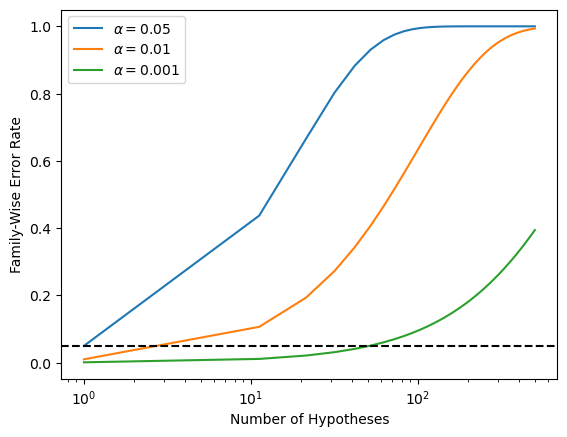

In [8]:
m = np.linspace(1, 501)
fig, ax = plt.subplots()
[ax.plot(m,
         1- (1- alpha)**m,
         label=r'$\alpha=%s$' % str(alpha))
         for alpha in [0.05, 0.01, 0.001]]
ax.set_xscale('log')
ax.set_xlabel('Number of Hypotheses')
ax.set_ylabel('Family-Wise Error Rate')
ax.legend()
ax.axhline(0.05, c='k', ls='--');

In [9]:
Fund = load_data('Fund')
fund_mini = Fund.iloc[:,:5]
fund_mini_pvals = np.empty(5)
for i in range(5):
    fund_mini_pvals[i] = ttest_1samp(fund_mini.iloc[:,i], 0).pvalue
fund_mini_pvals

array([0.00620236, 0.91827115, 0.01160098, 0.6005396 , 0.75578151])

In [10]:
reject, bonf = mult_test(fund_mini_pvals, method = "bonferroni")[:2]
reject

array([ True, False, False, False, False])

In [11]:
bonf, np.minimum(fund_mini_pvals * 5, 1)

(array([0.03101178, 1.        , 0.05800491, 1.        , 1.        ]),
 array([0.03101178, 1.        , 0.05800491, 1.        , 1.        ]))

In [12]:
mult_test(fund_mini_pvals, method = "holm", alpha=0.05)[:2]

(array([ True, False,  True, False, False]),
 array([0.03101178, 1.        , 0.04640393, 1.        , 1.        ]))

In [13]:
fund_mini.mean()

Manager1    3.0
Manager2   -0.1
Manager3    2.8
Manager4    0.5
Manager5    0.3
dtype: float64

In [14]:
ttest_rel(fund_mini['Manager1'],
          fund_mini['Manager2']).pvalue

np.float64(0.038391072368079586)

In [15]:
returns = np.hstack([fund_mini.iloc[:,i] for i in range(5)])
managers = np.hstack([[i+1]*50 for i in range(5)])
tukey = pairwise_tukeyhsd(returns, managers)
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2     -3.1 0.1862 -6.9865 0.7865  False
     1      3     -0.2 0.9999 -4.0865 3.6865  False
     1      4     -2.5 0.3948 -6.3865 1.3865  False
     1      5     -2.7 0.3152 -6.5865 1.1865  False
     2      3      2.9 0.2453 -0.9865 6.7865  False
     2      4      0.6 0.9932 -3.2865 4.4865  False
     2      5      0.4 0.9986 -3.4865 4.2865  False
     3      4     -2.3  0.482 -6.1865 1.5865  False
     3      5     -2.5 0.3948 -6.3865 1.3865  False
     4      5     -0.2 0.9999 -4.0865 3.6865  False
---------------------------------------------------


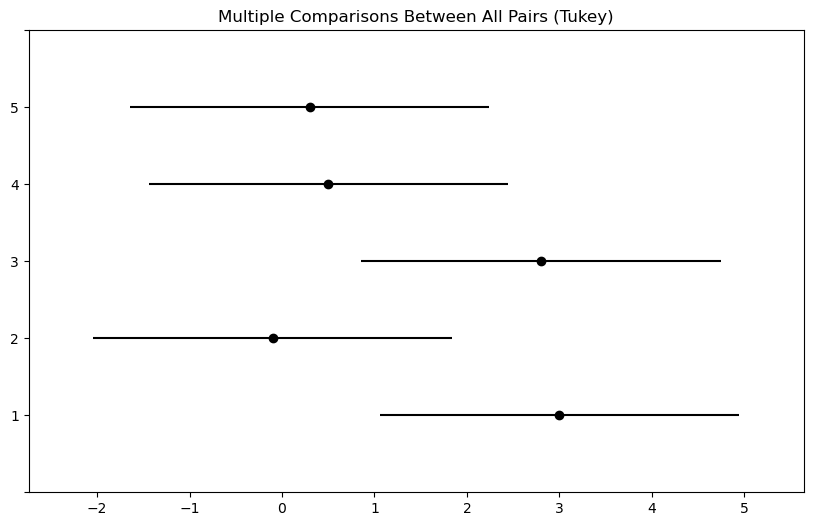

In [16]:
fig, ax = plt.subplots(figsize=(8,8))
tukey.plot_simultaneous(ax=ax);

##### False Discovery Rate

In [17]:
fund_pvalues = np.empty(2000)
for i, manager in enumerate(Fund.columns):
    fund_pvalues[i] = ttest_1samp(Fund[manager], 0).pvalue

In [18]:
fund_qvalues = mult_test(fund_pvalues, method = "fdr_bh")[1]
fund_qvalues[:10]

array([0.08988921, 0.991491  , 0.12211561, 0.92342997, 0.95603587,
       0.07513802, 0.0767015 , 0.07513802, 0.07513802, 0.07513802])

In [19]:
(fund_qvalues <= 0.1).sum()

np.int64(146)

In [20]:
(fund_pvalues <= 0.1 / 2000).sum()

np.int64(0)

In [21]:
sorted_ = np.sort(fund_pvalues)
m = fund_pvalues.shape[0]
q = 0.1
sorted_set_ = np.where(sorted_ < q * np.linspace(1, m, m) / m)[0]
if sorted_set_.shape[0] > 0:
    selected_ = fund_pvalues < sorted_[sorted_set_].max()
    sorted_set_ = np.arange(sorted_set_.max())
else:
    selected_ = []
    sorted_set_ = []


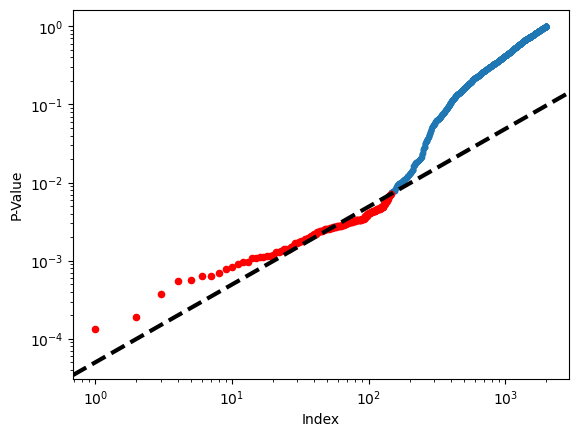

In [22]:
fig, ax = plt.subplots()
ax.scatter(np.arange(0, sorted_.shape[0]) + 1,
           sorted_, s=10)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('P-Value')
ax.set_xlabel('Index')
ax.scatter(sorted_set_+1, sorted_[sorted_set_], c='r', s=20)
ax.axline((0, 0), (1,q/m), c='k', ls='--', linewidth=3);

#####  A Re-Sampling Approach

In [23]:
Khan = load_data('Khan')
D = pd.concat([Khan['xtrain'], Khan['xtest']])
D['Y'] = pd.concat([Khan['ytrain'], Khan['ytest']])
D['Y'].value_counts()

Y
2    29
4    25
3    18
1    11
Name: count, dtype: int64

In [24]:
D2 = D[lambda df:df['Y'] == 2]
D4 = D[lambda df:df['Y'] == 4]
gene_11 = 'G0011'
observedT, pvalue = ttest_ind(D2[gene_11],
                              D4[gene_11],
                              equal_var=True)
observedT, pvalue

(np.float64(-2.0936330736768185), np.float64(0.04118643782678394))

In [25]:
B = 10000
Tnull = np.empty(B)
D_ = np.hstack([D2[gene_11], D4[gene_11]])
n_ = D2[gene_11].shape[0]
D_null = D_.copy()
for b in range(B):
    rng.shuffle(D_null)
    ttest_ = ttest_ind(D_null[:n_],
                       D_null[n_:],
                       equal_var=True)
    Tnull[b] = ttest_.statistic
(np.abs(Tnull) > np.abs(observedT)).mean()

np.float64(0.0398)

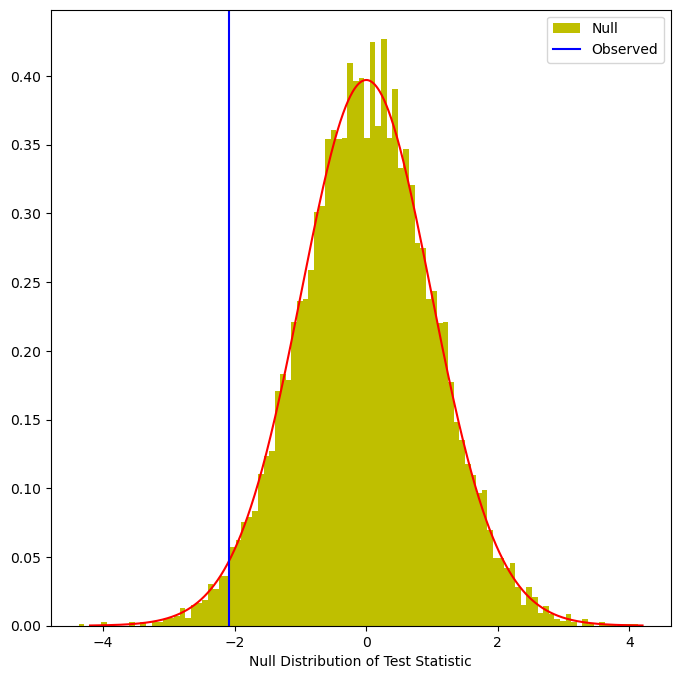

In [26]:
fig, ax = plt.subplots(figsize=(8,8))
ax.hist(Tnull,
        bins=100,
        density=True,
        facecolor='y',
        label='Null')
xval = np.linspace(-4.2, 4.2, 1001)
ax.plot(xval,
        t_dbn.pdf(xval, D_.shape[0]-2),
        c='r')
ax.axvline(observedT,
           c='b',
           label='Observed')
ax.legend()
ax.set_xlabel("Null Distribution of Test Statistic");

In [27]:
m, B = 100, 10000
idx = rng.choice(Khan['xtest'].columns, m, replace=False)
T_vals = np.empty(m)
Tnull_vals = np.empty((m, B))

for j in range(m):
    col = idx[j]
    T_vals[j] = ttest_ind(D2[col],
                          D4[col],
                          equal_var=True).statistic
    D_ = np.hstack([D2[col], D4[col]])
    D_null = D_.copy()
    for b in range(B):
        rng.shuffle(D_null)
        ttest_ = ttest_ind(D_null[:n_],
                           D_null[n_:],
                           equal_var=True)
        Tnull_vals[j,b] = ttest_.statistic

In [28]:
cutoffs = np.sort(np.abs(T_vals))
FDRs, Rs, Vs = np.empty((3, m))
for j in range(m):
    R = np.sum(np.abs(T_vals) >= cutoffs[j])
    V = np.sum(np.abs(Tnull_vals) >= cutoffs[j]) / B
    Rs[j] = R
    Vs[j] = V
    FDRs[j] = V / R

In [29]:
sorted(idx[np.abs(T_vals) >= cutoffs[FDRs < 0.1].min()])

['G0097',
 'G0129',
 'G0182',
 'G0714',
 'G0812',
 'G0941',
 'G0982',
 'G1020',
 'G1022',
 'G1090',
 'G1320',
 'G1634',
 'G1697',
 'G1853',
 'G1854',
 'G1994',
 'G2017',
 'G2115',
 'G2193']

In [30]:
sorted(idx[np.abs(T_vals) >= cutoffs[FDRs < 0.2].min()])

['G0097',
 'G0129',
 'G0158',
 'G0182',
 'G0242',
 'G0552',
 'G0679',
 'G0714',
 'G0751',
 'G0812',
 'G0908',
 'G0941',
 'G0982',
 'G1020',
 'G1022',
 'G1090',
 'G1240',
 'G1244',
 'G1320',
 'G1381',
 'G1514',
 'G1634',
 'G1697',
 'G1768',
 'G1853',
 'G1854',
 'G1907',
 'G1994',
 'G2017',
 'G2115',
 'G2193']

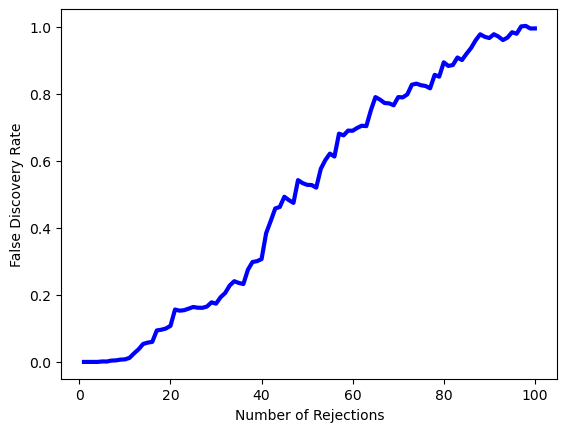

In [31]:
fig, ax = plt.subplots()
ax.plot(Rs, FDRs, 'b', linewidth=3)
ax.set_xlabel("Number of Rejections")
ax.set_ylabel("False Discovery Rate");

####  Exercises

$Conceptual$

1. Suppose we test $m$ null hypotheses, all of which are true. We control the Type I error for each null hypothesis at level $\alpha$. For each subproblem, justify your answer.
   
   a. In total, how many Type I errors do we expect to make?
   
   b. Suppose that the $m$ tests that we perform are independent. What is the family-wise error rate associated with these $m$ tests?  
   **Hint:** If two events $A$ and $B$ are independent, then $\Pr(A \cap B) = \Pr(A)\Pr(B)$.

   c. Suppose that $m = 2$, and that the p-values for the two tests are positively correlated, so that if one is small then the other will tend to be small as well, and if one is large then the other will tend to be large. How does the family-wise error rate associated with these $m = 2$ tests qualitatively compare to the answer in (b) with $m = 2$?  
   **Hint:** First, suppose that the two p-values are perfectly correlated.

   d. Suppose again that $m = 2$, but that now the p-values for the two tests are negatively correlated, so that if one is large then the other will tend to be small. How does the family-wise error rate associated with these $m = 2$ tests qualitatively compare to the answer in (b) with $m = 2$?  
   **Hint:** First, suppose that whenever one p-value is less than $\alpha$, then the other will be greater than $\alpha$. In other words, we can never reject both null hypotheses.

**(a): Expected Number of Type I Errors**

Since each test is controlled at level $\alpha$, the probability of a Type I error on any single test is $\alpha$. With $m$ independent tests, the expected number of Type I errors is:

$$\mathbb{E}[\text{Type I errors}] = m\alpha$$

This follows directly from the linearity of expectation: if $X_i \in \{0,1\}$ indicates a Type I error on test $i$, then $\mathbb{E}[X_i] = \alpha$ and $\mathbb{E}[\sum_{i=1}^m X_i] = m\alpha$.



**(b): FWER with Independent Tests**

The **family-wise error rate (FWER)** is the probability of making *at least one* Type I error. Using the complement:

$$\text{FWER} = \Pr(\text{at least one Type I error}) = 1 - \Pr(\text{no Type I errors})$$

Since the tests are independent, by the hint:

$$\Pr(\text{no Type I errors}) = \prod_{i=1}^{m} \Pr(\text{no Type I error on test } i) = (1 - \alpha)^m$$

Therefore:

$$\boxed{\text{FWER} = 1 - (1-\alpha)^m}$$

This grows rapidly toward 1 as $m$ increases. For example, with $\alpha = 0.05$ and $m = 100$: $\text{FWER} = 1 - (0.95)^{100} \approx 0.994$.


**(c): $m = 2$ with Positively Correlated P-values**

With $m = 2$ independent tests, from part (b): $\text{FWER} = 1 - (1-\alpha)^2 = 2\alpha - \alpha^2$.

Now consider the **perfectly correlated** extreme: if one p-value is small, the other is *always* small too, and vice versa. This means we either reject *both* hypotheses or *neither*. The probability of rejecting both (making at least one error) equals the probability of rejecting just one, which is simply $\alpha$:

$$\text{FWER}_{\text{perfect}} = \alpha < 2\alpha - \alpha^2 = \text{FWER}_{\text{independent}}$$

**Conclusion:** Positive correlation *reduces* the FWER compared to the independent case. Intuitively, when p-values move together, the tests are not providing truly independent "shots" at a false rejection — a single unlucky draw tends to affect all tests simultaneously rather than creating separate chances for errors.

$$\text{FWER}_{\text{positive corr}} \leq \text{FWER}_{\text{independent}} = 1-(1-\alpha)^2$$


**(d): $m = 2$ with Negatively Correlated P-values**

Consider the **perfectly negatively correlated** extreme described in the hint: whenever one p-value is $< \alpha$, the other is $> \alpha$. This means we can *never* reject both null hypotheses simultaneously.

However, we *can* still reject exactly one of them. In fact, we are more likely to reject at least one because when one p-value is large, the other is forced to be small. The probability of at least one rejection is **higher** than in the independent case:

$$\text{FWER}_{\text{negative corr}} \geq \text{FWER}_{\text{independent}} = 1-(1-\alpha)^2$$

In the perfect case: $\Pr(\text{reject at least one}) \approx 2\alpha$ (approximately, when $\alpha$ is small), which is larger than $2\alpha - \alpha^2$.

**Conclusion:** Negative correlation *increases* the FWER compared to the independent case. The tests compensate for each other, increasing the combined chance that *at least one* will be a false rejection.

$$\text{FWER}_{\text{negative corr}} \geq \text{FWER}_{\text{independent}} \geq \text{FWER}_{\text{positive corr}}$$

2. Suppose that we test $m$ hypotheses, and control the Type I error for each hypothesis at level $\alpha$. Assume that all $m$ p-values are independent, and that all null hypotheses are true.
   a. Let the random variable $A_j$ equal 1 if the $j$th null hypothesis is rejected, and 0 otherwise. What is the distribution of $A_j$?
   
   b. What is the distribution of $\sum_{j=1}^{m} A_j$?
   
   c. What is the standard deviation of the number of Type I errors that we will make?


**(a): Distribution of $A_j$**

$A_j$ indicates whether the $j$th null hypothesis is rejected. Since we control Type I error at level $\alpha$ and the null is true:

$$\Pr(A_j = 1) = \alpha \qquad \Pr(A_j = 0) = 1 - \alpha$$

Therefore $A_j$ follows a **Bernoulli distribution**:

$$\boxed{A_j \sim \text{Bernoulli}(\alpha)}$$


**(b): Distribution of $\sum_{j=1}^{m} A_j$**

The total number of Type I errors is $\sum_{j=1}^{m} A_j$, which is a sum of $m$ **independent** Bernoulli($\alpha$) random variables (independent because all $m$ p-values are assumed independent).

A sum of $m$ independent Bernoulli($p$) trials follows a **Binomial distribution**:

$$\boxed{\sum_{j=1}^{m} A_j \sim \text{Binomial}(m,\ \alpha)}$$

This makes intuitive sense: each of the $m$ tests is an independent "trial" with success probability $\alpha$ (where "success" here means a Type I error).


**(c): Standard Deviation of Type I Errors**

For a $\text{Binomial}(m, \alpha)$ random variable, the variance is $m\alpha(1-\alpha)$, so the standard deviation is:

$$\boxed{\text{SD}\!\left(\sum_{j=1}^{m} A_j\right) = \sqrt{m\alpha(1-\alpha)}}$$

**Intuition:** The expected number of errors from Q1(a) is $m\alpha$, and it grows linearly in $m$, while the standard deviation only grows as $\sqrt{m}$. This means that as $m$ grows large, the *relative* variability (coefficient of variation $= 1/\sqrt{m\alpha/(1-\alpha)}$) shrinks — the number of false rejections concentrates tightly around $m\alpha$.


3. Suppose we test $m$ null hypotheses, and control the Type I error for the $j$th null hypothesis at level $\alpha_j$, for $j = 1, \ldots, m$. Argue that the family-wise error rate is no greater than $\sum_{j=1}^{m} \alpha_j$.

| Null Hypothesis | p-value |
|-----------------|---------|
| $H_{01}$      | 0.0011  |
| $H_{02}$      | 0.031   |
| $H_{03}$      | 0.017   |
| $H_{04}$      | 0.32    |
| $H_{05}$      | 0.11    |
| $H_{06}$      | 0.90    |
| $H_{07}$      | 0.07    |
| $H_{08}$      | 0.006   |
| $H_{09}$      | 0.004   |
| $H_{10}$      | 0.0009  |

**TABLE 13.4. p-values for Exercise 4.**


**Proof: FWER $\leq \sum_{j=1}^{m} \alpha_j$ (Bonferroni Bound)**

Let $\mathcal{H}_0$ be the set of **true** null hypotheses, and let $E_j$ be the event that we make a Type I error on hypothesis $j$ (i.e., we reject $H_{0j}$ when it is true). By definition, $\Pr(E_j) = \alpha_j$.

The FWER is the probability of making **at least one** Type I error among all true nulls:

$$\text{FWER} = \Pr\!\left(\bigcup_{j \in \mathcal{H}_0} E_j\right)$$

Applying the **union bound** (Boole's inequality), which holds for *any* events regardless of their dependence structure:

$$\Pr\!\left(\bigcup_{j \in \mathcal{H}_0} E_j\right) \leq \sum_{j \in \mathcal{H}_0} \Pr(E_j) = \sum_{j \in \mathcal{H}_0} \alpha_j \leq \sum_{j=1}^{m} \alpha_j$$

Therefore:

$$\boxed{\text{FWER} \leq \sum_{j=1}^{m} \alpha_j}$$

The last inequality holds because summing over all $m$ hypotheses can only be $\geq$ summing over the true null subset $\mathcal{H}_0 \subseteq \{1,\ldots,m\}$.

**Key insight:** This bound requires **no assumptions** about the dependence structure of the tests. The **Bonferroni correction** exploits this directly — by setting each $\alpha_j = \alpha/m$, we guarantee:

$$\text{FWER} \leq \sum_{j=1}^{m} \frac{\alpha}{m} = \alpha$$

The bound is tight (nearly exact) when $m$ is small and tests are independent, but becomes increasingly conservative as $m$ grows large or as tests become positively correlated, since positively correlated errors are "double-counted" in the sum.


4. Suppose we test $m = 10$ hypotheses, and obtain the p-values shown in Table 13.4.
   
   a. Suppose that we wish to control the Type I error for each null hypothesis at level $\alpha = 0.05$. Which null hypotheses will we reject?
   
   b. Now suppose that we wish to control the FWER at level $\alpha = 0.05$. Which null hypotheses will we reject? Justify your answer.
   
   c. Now suppose that we wish to control the FDR at level $q = 0.05$. Which null hypotheses will we reject? Justify your answer.
   
   d. Now suppose that we wish to control the FDR at level $q = 0.2$. Which null hypotheses will we reject? Justify your answer.
   
   e. Of the null hypotheses rejected at FDR level $q = 0.2$, approximately how many are false positives? Justify your answer.


In [32]:
import pandas as pd
import numpy as np

# Data
hypotheses = [f'H₀{i:02d}' for i in range(1, 11)]
pvalues = [0.0011, 0.031, 0.017, 0.32, 0.11, 0.90, 0.07, 0.006, 0.004, 0.0009]
m = len(pvalues)
alpha = 0.05

df = pd.DataFrame({'Hypothesis': hypotheses, 'p-value': pvalues})

# ── Part (a): Individual α = 0.05 ─────────────────────────────────────────────
print("=" * 65)
print("PART (a): Reject if p-value < α = 0.05 (no correction)")
print("=" * 65)
df['Reject (a)'] = df['p-value'] < alpha
print(df[['Hypothesis', 'p-value', 'Reject (a)']].to_string(index=False))
print(f"\nRejected: {list(df.loc[df['Reject (a)'], 'Hypothesis'])}")

# ── Part (b): FWER via Bonferroni ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("PART (b): FWER control via Bonferroni (threshold = α/m)")
print("=" * 65)
bonferroni_thresh = alpha / m
df['Reject (b)'] = df['p-value'] < bonferroni_thresh
print(f"Bonferroni threshold = {alpha}/{m} = {bonferroni_thresh:.4f}")
print(df[['Hypothesis', 'p-value', 'Reject (b)']].to_string(index=False))
print(f"\nRejected: {list(df.loc[df['Reject (b)'], 'Hypothesis'])}")

# ── Part (c) & (d): FDR via Benjamini-Hochberg ────────────────────────────────
def benjamini_hochberg(df, q):
    """Apply BH procedure and return augmented DataFrame."""
    bh = (df[['Hypothesis', 'p-value']]
            .copy()
            .sort_values('p-value')
            .reset_index(drop=True))
    bh['Rank (j)']    = np.arange(1, m + 1)
    bh['BH threshold (j·q/m)'] = bh['Rank (j)'] * q / m

    # Largest j where p_(j) <= j*q/m
    eligible = bh[bh['p-value'] <= bh['BH threshold (j·q/m)']]
    cutoff_rank = eligible['Rank (j)'].max() if not eligible.empty else 0
    bh['Reject'] = bh['Rank (j)'] <= cutoff_rank
    return bh, cutoff_rank

for q, part in [(0.05, 'c'), (0.2, 'd')]:
    print("\n" + "=" * 65)
    print(f"PART ({part}): FDR control via Benjamini-Hochberg at q = {q}")
    print("=" * 65)
    bh, k = benjamini_hochberg(df, q)
    print(f"{'Hypothesis':<12} {'p-value':>9} {'Rank j':>8} "
          f"{'j·q/m':>12} {'Reject':>8}")
    print("-" * 55)
    for _, row in bh.iterrows():
        flag = "✓" if row['Reject'] else ""
        print(f"{row['Hypothesis']:<12} {row['p-value']:>9.4f} "
              f"{int(row['Rank (j)']):>8} "
              f"{row['BH threshold (j·q/m)']:>12.4f} {flag:>8}")
    rejected = bh.loc[bh['Reject'], 'Hypothesis'].tolist()
    print(f"\nLargest j where p_(j) ≤ j·q/m: j = {k}")
    print(f"Rejected (all hypotheses with rank ≤ {k}): {rejected}")

# ── Part (e): Expected false positives at q = 0.2 ────────────────────────────
print("\n" + "=" * 65)
print("PART (e): Expected false positives among rejections at q = 0.2")
print("=" * 65)
bh_02, k_02 = benjamini_hochberg(df, 0.2)
n_rejected = int(bh_02['Reject'].sum())
expected_fp = q * n_rejected   # q = 0.2, FDR definition: E[V/R] = q
print(f"Number of rejections (R)           : {n_rejected}")
print(f"FDR level (q)                      : 0.2")
print(f"Expected false positives ≈ q · R   : 0.2 × {n_rejected} = {expected_fp:.1f}")
print(f"\n∴ We expect approximately {expected_fp:.0f} false positive(s) among the "
      f"{n_rejected} rejections.")

PART (a): Reject if p-value < α = 0.05 (no correction)
Hypothesis  p-value  Reject (a)
      H₀01   0.0011        True
      H₀02   0.0310        True
      H₀03   0.0170        True
      H₀04   0.3200       False
      H₀05   0.1100       False
      H₀06   0.9000       False
      H₀07   0.0700       False
      H₀08   0.0060        True
      H₀09   0.0040        True
      H₀10   0.0009        True

Rejected: ['H₀01', 'H₀02', 'H₀03', 'H₀08', 'H₀09', 'H₀10']

PART (b): FWER control via Bonferroni (threshold = α/m)
Bonferroni threshold = 0.05/10 = 0.0050
Hypothesis  p-value  Reject (b)
      H₀01   0.0011        True
      H₀02   0.0310       False
      H₀03   0.0170       False
      H₀04   0.3200       False
      H₀05   0.1100       False
      H₀06   0.9000       False
      H₀07   0.0700       False
      H₀08   0.0060       False
      H₀09   0.0040        True
      H₀10   0.0009        True

Rejected: ['H₀01', 'H₀09', 'H₀10']

PART (c): FDR control via Benjamini-Hochberg at

**(a): Individual Testing at $\alpha = 0.05$**

Reject any hypothesis with p-value $< 0.05$ — **no correction applied**:

**Rejected:** H₀₁ (0.0011), H₀₂ (0.031), H₀₃ (0.017), H₀₈ (0.006), H₀₉ (0.004), H₀₁₀ (0.0009) — **6 rejections**


**(b): FWER Control via Bonferroni at $\alpha = 0.05$**

The Bonferroni correction rejects $H_{0j}$ when $p_j < \alpha/m = 0.05/10 = 0.005$. This guarantees FWER $\leq \alpha$ regardless of dependence structure.

**Rejected:** H₀₁ (0.0011), H₀₉ (0.004), H₀₁₀ (0.0009) — **3 rejections**

H₀₈ (p = 0.006) is *not* rejected because $0.006 > 0.005$ — demonstrating Bonferroni's conservatism.


**(c) & (d): FDR Control via Benjamini-Hochberg**

The **BH procedure**: sort p-values $p_{(1)} \leq \cdots \leq p_{(m)}$, find the largest $j$ such that $p_{(j)} \leq \frac{j \cdot q}{m}$, then reject all hypotheses with rank $\leq j$.

**At $q = 0.05$:** Largest qualifying rank is $j=5$ (H₀₃, $p=0.017 \leq 5 \times 0.05/10 = 0.025$). H₀₂ fails since $0.031 > 0.030$.

**Rejected:** H₀₁₀, H₀₁, H₀₉, H₀₈, H₀₃ — **5 rejections** *(2 more than Bonferroni, 1 fewer than uncorrected)*

**At $q = 0.20$:** Largest qualifying rank is $j=8$ (H₀₅, $p=0.11 \leq 8 \times 0.20/10 = 0.16$). H₀₄ fails since $0.32 > 0.18$.

**Rejected:** H₀₁₀, H₀₁, H₀₉, H₀₈, H₀₃, H₀₂, H₀₇, H₀₅ — **8 rejections**


**(e): Expected False Positives at $q = 0.2$**

By the definition of FDR, the BH procedure controls:

$$\text{FDR} = \mathbb{E}\!\left[\frac{V}{R}\right] \leq q$$

where $V$ = false positives and $R$ = total rejections. Therefore the expected number of false positives is:

$$\mathbb{E}[V] \approx q \times R = 0.2 \times 8 = \boxed{1.6}$$

We expect roughly **1 to 2 false positives** among the 8 rejections. This is the FDR trade-off: by relaxing from FWER to FDR control and raising $q$ to 0.2, we gain 5 additional rejections (vs. Bonferroni) while tolerating ~20% of them being false positives.


5. For this problem, you will make up p-values that lead to a certain number of rejections using the Bonferroni and Holm procedures.

(a) Give an example of five p-values (i.e. five numbers between 0 and 1 which, for the purpose of this problem, we will interpret as p-values) for which both Bonferroni’s method and Holm’s method reject exactly one null hypothesis when controlling the FWER at level 0.1.

(b) Now give an example of five p-values for which Bonferroni rejects one null hypothesis and Holm rejects more than one null hypothesis at level 0.1.
 

In [33]:
import numpy as np
import pandas as pd

def bonferroni(pvalues, alpha=0.1):
    """Reject H_0j if p_j < alpha/m"""
    m = len(pvalues)
    threshold = alpha / m
    rejected = [p < threshold for p in pvalues]
    return rejected, threshold

def holm(pvalues, alpha=0.1):
    """
    Holm's step-down procedure:
    Sort p-values. For rank j (1-indexed), reject if
    p_(j) < alpha / (m - j + 1). Stop at first non-rejection.
    """
    m = len(pvalues)
    order = np.argsort(pvalues)
    sorted_p = np.array(pvalues)[order]
    thresholds = [alpha / (m - j) for j in range(m)]  # j=0..m-1 → alpha/(m), alpha/(m-1), ...

    rejected_sorted = [False] * m
    for j in range(m):
        if sorted_p[j] < thresholds[j]:
            rejected_sorted[j] = True
        else:
            break  # step-down: stop at first failure

    # Map back to original order
    rejected = [False] * m
    for rank, orig_idx in enumerate(order):
        rejected[orig_idx] = rejected_sorted[rank]
    return rejected, thresholds

def display_results(label, pvalues, alpha=0.1):
    m = len(pvalues)
    bon_rej, bon_thresh = bonferroni(pvalues, alpha)
    holm_rej, holm_thresh = holm(pvalues, alpha)

    # Build sorted BH-style table for Holm display
    order = np.argsort(pvalues)
    sorted_p = np.array(pvalues)[order]
    holm_thresholds_sorted = [alpha / (m - j) for j in range(m)]

    print(f"\n{'='*66}")
    print(f" {label}")
    print(f"{'='*66}")
    print(f"  Bonferroni threshold : α/m = {alpha}/{m} = {alpha/m:.4f}")
    print(f"  {'Hypothesis':<10} {'p-value':>9} {'< α/m?':>10} {'Bonferroni':>12}")
    print(f"  {'-'*44}")
    for i, (p, r) in enumerate(zip(pvalues, bon_rej)):
        mark = "REJECT" if r else "-"
        print(f"  H₀{i+1:<8} {p:>9.4f} {str(p < bon_thresh):>10} {mark:>12}")
    print(f"\n  Bonferroni rejections : {sum(bon_rej)}")

    print(f"\n  Holm Step-Down (sorted p-values):")
    print(f"  {'Rank j':<8} {'Hypothesis':<10} {'p_(j)':>9} {'α/(m-j+1)':>12} {'Reject?':>9}")
    print(f"  {'-'*52}")
    holm_rej_sorted = [False] * m
    stop = False
    for j, orig_idx in enumerate(order):
        thresh = holm_thresholds_sorted[j]
        if not stop and sorted_p[j] < thresh:
            decision = "REJECT"
            holm_rej_sorted[j] = True
        else:
            decision = "STOP" if not stop else "-"
            stop = True
        print(f"  {j+1:<8} H₀{orig_idx+1:<8} {sorted_p[j]:>9.4f} {thresh:>12.4f} {decision:>9}")
    print(f"\n  Holm rejections       : {sum(holm_rej)}")

# ── Part (a): Both reject exactly 1 ─────────────────────────────────────────
# Need: p_(1) < α/m = 0.02  (so Bonferroni rejects it)
# But:  p_(2) >= α/(m-1) = 0.025  (so Holm stops after 1)
pvalues_a = [0.015, 0.06, 0.15, 0.38, 0.72]
display_results("PART (a): Both Bonferroni and Holm reject exactly 1", pvalues_a)

# ── Part (b): Bonferroni rejects 1, Holm rejects more ────────────────────────
# Need: p_(1) < 0.02 (Bonferroni rejects 1)
#        p_(2) < α/(m-1) = 0.025 (Holm keeps going)
#        p_(3) < α/(m-2) = 0.033 (Holm keeps going)  
#        p_(4) >= α/(m-3) = 0.05  (Holm stops)
# So Bonferroni rejects only p_(1) since p_(2)=0.024 > 0.02
pvalues_b = [0.015, 0.024, 0.031, 0.07, 0.55]
display_results("PART (b): Bonferroni rejects 1, Holm rejects more than 1", pvalues_b)


 PART (a): Both Bonferroni and Holm reject exactly 1
  Bonferroni threshold : α/m = 0.1/5 = 0.0200
  Hypothesis   p-value     < α/m?   Bonferroni
  --------------------------------------------
  H₀1           0.0150       True       REJECT
  H₀2           0.0600      False            -
  H₀3           0.1500      False            -
  H₀4           0.3800      False            -
  H₀5           0.7200      False            -

  Bonferroni rejections : 1

  Holm Step-Down (sorted p-values):
  Rank j   Hypothesis     p_(j)    α/(m-j+1)   Reject?
  ----------------------------------------------------
  1        H₀1           0.0150       0.0200    REJECT
  2        H₀2           0.0600       0.0250      STOP
  3        H₀3           0.1500       0.0333         -
  4        H₀4           0.3800       0.0500         -
  5        H₀5           0.7200       0.1000         -

  Holm rejections       : 1

 PART (b): Bonferroni rejects 1, Holm rejects more than 1
  Bonferroni threshold : α/m = 0

**Key: How the two procedures work**

**Bonferroni** rejects $H_{0j}$ if $p_j < \alpha/m$ — a single fixed threshold for all tests.

**Holm's step-down** sorts p-values $p_{(1)} \leq \cdots \leq p_{(m)}$ and uses *decreasing* thresholds. Reject $H_{(j)}$ if $p_{(j)} < \alpha/(m - j + 1)$, stopping at the first failure. This is **always at least as powerful** as Bonferroni, since the thresholds at every step $j \geq 2$ satisfy $\alpha/(m-j+1) > \alpha/m$.



**(a): Both reject exactly 1 — $p = [0.015,\ 0.06,\ 0.15,\ 0.38,\ 0.72]$**

**Bonferroni** threshold $= \alpha/m = 0.1/5 = 0.020$. Only $p_1 = 0.015 < 0.020$ → **1 rejection**.

**Holm** step-down: $p_{(1)} = 0.015 < 0.020$ → reject. Then $p_{(2)} = 0.06 \geq 0.025$ → **STOP**. → **1 rejection**.

Both agree because the gap between $p_{(1)}$ and $p_{(2)}$ is large enough that even Holm's more generous second threshold ($0.025$) cannot reach $p_{(2)} = 0.06$.


**(b): Bonferroni rejects 1, Holm rejects 3 — $p = [0.015,\ 0.024,\ 0.031,\ 0.07,\ 0.55]$**

**Bonferroni** threshold $= 0.020$. Only $p_1 = 0.015 < 0.020$ → **1 rejection**. ($p_2 = 0.024 > 0.020$, so it's missed.)

**Holm** step-down:

| Rank $j$ | $p_{(j)}$ | Threshold $\alpha/(m-j+1)$ | Decision |
|:---:|:---:|:---:|:---:|
| 1 | 0.015 | 0.0200 | **REJECT** |
| 2 | 0.024 | 0.0250 | **REJECT** |
| 3 | 0.031 | 0.0333 | **REJECT** |
| 4 | 0.070 | 0.0500 | STOP |

Holm rejects **3 hypotheses** — demonstrating its strictly greater power. Once $H_{(1)}$ is rejected, Holm "spends" less of the error budget on remaining tests, giving $p_{(2)}$ and $p_{(3)}$ increasingly lenient thresholds to clear.

6. For each of the three panels in Figure 13.3, answer the following questions:
   
   a. How many false positives, false negatives, true positives, true negatives, Type I errors, and Type II errors result from applying the Bonferroni procedure to control the FWER at level $\alpha = 0.05$?
   
   b. How many false positives, false negatives, true positives, true negatives, Type I errors, and Type II errors result from applying the Holm procedure to control the FWER at level $\alpha = 0.05$?
   
   c. What is the false discovery proportion associated with using the Bonferroni procedure to control the FWER at level $\alpha = 0.05$?
   
   d. What is the false discovery proportion associated with using the Holm procedure to control the FWER at level $\alpha = 0.05$?
   
   e. How would the answers to (a) and (c) change if we instead used the Bonferroni procedure to control the FWER at level $\alpha = 0.001$?

**Setup (all panels)**

| Quantity | Value |
|:---|:---:|
| Total hypotheses $m$ | 10 |
| True nulls $m_0$ | 2 (black dots) |
| False nulls $m - m_0$ | 8 (red dots) |

Recall the classification framework:

| | **Null True** | **Null False** |
|:---|:---:|:---:|
| **Reject** | False Positive (Type I) | True Positive |
| **Don't Reject** | True Negative | False Negative (Type II) |

**False Discovery Proportion (FDP)** $= V/R$ where $V$ = false positives, $R$ = total rejections (0 if $R=0$).


**Panel 1 (Left): Bonferroni and Holm reject the same hypotheses**

**(a) Bonferroni**

From the document: only the smallest red points fall below the Bonferroni line ($\alpha/m = 0.005$); both black dots remain above.

Reading the panel — Bonferroni rejects **3** red hypotheses:

| Metric | Value | Reasoning |
|:---|:---:|:---|
| True Positives | 3 | 3 red dots below Bonferroni line |
| False Positives (Type I) | 0 | No black dots rejected |
| True Negatives | 2 | Both black dots correctly not rejected |
| False Negatives (Type II) | 5 | 5 red dots above Bonferroni line |

**(b) Holm**

Holm rejects the **same set** as Bonferroni in Panel 1 — blue curve coincides with black line for these points:

| Metric | Value |
|:---|:---:|
| True Positives | 3 |
| False Positives (Type I) | 0 |
| True Negatives | 2 |
| False Negatives (Type II) | 5 |

**(c) FDP — Bonferroni**

$$\text{FDP} = \frac{V}{R} = \frac{0}{3} = \boxed{0}$$

**(d) FDP — Holm**

$$\text{FDP} = \frac{0}{3} = \boxed{0}$$

**(e) Bonferroni at $\alpha = 0.001$**

New threshold $= 0.001/10 = 0.0001$ — far more conservative. The previously rejected red dots (which had p-values around $0.001$–$0.005$) now likely **fail** to clear this threshold, so **0 rejections**:

| Metric | Change |
|:---|:---|
| True Positives | $3 \to 0$ (fewer rejections) |
| False Positives | remains **0** |
| True Negatives | remains **2** |
| False Negatives | $5 \to 8$ (all false nulls missed) |
| FDP | $0/0$, defined as **0** (no rejections made) |


**Panel 2 (Center): Holm rejects 1 more than Bonferroni**

**(a) Bonferroni**

Bonferroni rejects **4** red hypotheses (the smallest red points below $\alpha/m = 0.005$):

| Metric | Value | Reasoning |
|:---|:---:|:---|
| True Positives | 4 | 4 red dots below Bonferroni line |
| False Positives (Type I) | 0 | No black dots rejected |
| True Negatives | 2 | Both black dots not rejected |
| False Negatives (Type II) | 4 | 4 red dots above Bonferroni line |

**(b) Holm**

Holm rejects **1 additional red** hypothesis (between the blue and black lines):

| Metric | Value | Reasoning |
|:---|:---:|:---|
| True Positives | 5 | 4 Bonferroni + 1 extra red |
| False Positives (Type I) | 0 | Still no black dots rejected |
| True Negatives | 2 | Both black dots not rejected |
| False Negatives (Type II) | 3 | 1 fewer false negative than Bonferroni |

**(c) FDP — Bonferroni**

$$\text{FDP} = \frac{0}{4} = \boxed{0}$$

**(d) FDP — Holm**

$$\text{FDP} = \frac{0}{5} = \boxed{0}$$

**(e) Bonferroni at $\alpha = 0.001$**

Threshold $= 0.0001$ — only the very smallest p-value(s) survive; likely **1** rejection:

| Metric | Change |
|:---|:---|
| True Positives | $4 \to 1$ |
| False Positives | remains **0** |
| True Negatives | remains **2** |
| False Negatives | $4 \to 7$ |
| FDP | $0/1 = \mathbf{0}$ |


**Panel 3 (Right): Holm rejects 5 more than Bonferroni**

**(a) Bonferroni**

Bonferroni rejects only the **smallest few** red points — **2** rejections:

| Metric | Value | Reasoning |
|:---|:---:|:---|
| True Positives | 2 | Only 2 red dots below Bonferroni line |
| False Positives (Type I) | 0 | No black dots rejected |
| True Negatives | 2 | Both black dots not rejected |
| False Negatives (Type II) | 6 | 6 red dots above Bonferroni line |

**(b) Holm**

Holm rejects **5 additional red** hypotheses (between blue and black lines):

| Metric | Value | Reasoning |
|:---|:---:|:---|
| True Positives | 7 | 2 Bonferroni + 5 extra red |
| False Positives (Type I) | 0 | Still no black dots rejected |
| True Negatives | 2 | Both black dots not rejected |
| False Negatives (Type II) | 1 | Only 1 false null still missed |

**(c) FDP — Bonferroni**

$$\text{FDP} = \frac{0}{2} = \boxed{0}$$

**(d) FDP — Holm**

$$\text{FDP} = \frac{0}{7} = \boxed{0}$$

**(e) Bonferroni at $\alpha = 0.001$**

Threshold $= 0.0001$ — extremely conservative; likely **0 rejections**:

| Metric | Change |
|:---|:---|
| True Positives | $2 \to 0$ |
| False Positives | remains **0** |
| True Negatives | remains **2** |
| False Negatives | $6 \to 8$ (all 8 false nulls missed) |
| FDP | $0/0$, defined as **0** |


**Summary Across All Panels**

| Panel | Procedure | TP | FP | TN | FN | FDP |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | Bonferroni | 3 | 0 | 2 | 5 | 0 |
| 1 | Holm | 3 | 0 | 2 | 5 | 0 |
| 2 | Bonferroni | 4 | 0 | 2 | 4 | 0 |
| 2 | Holm | 5 | 0 | 2 | 3 | 0 |
| 3 | Bonferroni | 2 | 0 | 2 | 6 | 0 |
| 3 | Holm | 7 | 0 | 2 | 1 | 0 |

> **Key insight:** The FDP is 0 in every case because both procedures successfully control the FWER — no true null (black dot) is ever rejected. However, Bonferroni pays a steep price in **Type II errors** (false negatives), while Holm's adaptive thresholds recover substantially more **true positives**, particularly in Panel 3 where it finds 5 additional discoveries at no cost to FWER control.

$Applied$

7. This problem makes use of the `Carseats` dataset in the `ISLP` package.
   
   a. For each quantitative variable in the dataset besides `Sales`, fit a linear model to predict `Sales` using that quantitative variable. Report the p-values associated with the coefficients for the variables. That is, for each model of the form $Y = \beta_0 + \beta_1 X + \epsilon$, report the p-value associated with the coefficient $\beta_1$. Here, $Y$ represents `Sales` and $X$ represents one of the other quantitative variables.
   
   b. Suppose we control the Type I error at level $\alpha = 0.05$ for the p-values obtained in (a). Which null hypotheses do we reject?
   
   c. Now suppose we control the FWER at level 0.05 for the p-values. Which null hypotheses do we reject?
   
   d. Finally, suppose we control the FDR at level 0.2 for the p-values. Which null hypotheses do we reject?


In [34]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from ISLP import load_data

# Load dataset
carseats = load_data('Carseats')

# ── Identify quantitative variables (excluding Sales) ─────────────────────────
quant_vars = carseats.select_dtypes(include=[np.number]).columns.tolist()
quant_vars = [v for v in quant_vars if v != 'Sales']
print(f"Quantitative predictors: {quant_vars}\n")

# ── Part (a): Fit simple linear models, collect p-values ─────────────────────
print("=" * 62)
print("PART (a): p-values from simple linear regressions")
print("=" * 62)

results = []
for var in quant_vars:
    X = sm.add_constant(carseats[var])
    y = carseats['Sales']
    model = sm.OLS(y, X).fit()
    pval  = model.pvalues[var]
    coef  = model.params[var]
    results.append({'Variable': var, 'Coefficient β₁': coef, 'p-value': pval})

df = pd.DataFrame(results).sort_values('p-value').reset_index(drop=True)
print(df.to_string(index=False, float_format='{:.6f}'.format))

alpha = 0.05

# ── Part (b): No correction — reject if p < 0.05 ─────────────────────────────
print(f"\n{'='*62}")
print(f"PART (b): No correction — reject if p-value < α = {alpha}")
print(f"{'='*62}")
df['Reject (b)'] = df['p-value'] < alpha
print(df[['Variable','p-value','Reject (b)']].to_string(index=False,
      float_format='{:.6f}'.format))
print(f"\nRejected: {df.loc[df['Reject (b)'], 'Variable'].tolist()}")

# ── Part (c): Bonferroni FWER control ─────────────────────────────────────────
print(f"\n{'='*62}")
print(f"PART (c): Bonferroni FWER — reject if p-value < α/m")
print(f"{'='*62}")
m = len(df)
bon_thresh = alpha / m
df['Reject (c)'] = df['p-value'] < bon_thresh
print(f"Bonferroni threshold = {alpha}/{m} = {bon_thresh:.6f}")
print(df[['Variable','p-value','Reject (c)']].to_string(index=False,
      float_format='{:.6f}'.format))
print(f"\nRejected: {df.loc[df['Reject (c)'], 'Variable'].tolist()}")

# ── Part (d): Benjamini-Hochberg FDR control ──────────────────────────────────
print(f"\n{'='*62}")
print(f"PART (d): Benjamini-Hochberg FDR — q = 0.20")
print(f"{'='*62}")
q = 0.20
bh = df[['Variable','p-value']].copy().sort_values('p-value').reset_index(drop=True)
bh['Rank j']         = np.arange(1, m + 1)
bh['BH thresh j·q/m'] = bh['Rank j'] * q / m

eligible    = bh[bh['p-value'] <= bh['BH thresh j·q/m']]
cutoff_rank = eligible['Rank j'].max() if not eligible.empty else 0
bh['Reject (d)'] = bh['Rank j'] <= cutoff_rank

print(f"{'Variable':<14} {'p-value':>10} {'Rank j':>8} "
      f"{'j·q/m':>12} {'Reject':>8}")
print("-" * 56)
for _, row in bh.iterrows():
    flag = "Yes" if row['Reject (d)'] else "No"
    print(f"{row['Variable']:<14} {row['p-value']:>10.6f} "
          f"{int(row['Rank j']):>8} {row['BH thresh j·q/m']:>12.6f} {flag:>8}")

print(f"\nLargest j where p_(j) ≤ j·q/m : j = {cutoff_rank}")
print(f"Rejected: {bh.loc[bh['Reject (d)'], 'Variable'].tolist()}")

Quantitative predictors: ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education']

PART (a): p-values from simple linear regressions
   Variable  Coefficient β₁  p-value
      Price       -0.053073 0.000000
Advertising        0.114448 0.000000
        Age       -0.040411 0.000003
     Income        0.015334 0.002310
  CompPrice        0.011801 0.200940
  Education       -0.055992 0.299944
 Population        0.000967 0.313982

PART (b): No correction — reject if p-value < α = 0.05
   Variable  p-value  Reject (b)
      Price 0.000000        True
Advertising 0.000000        True
        Age 0.000003        True
     Income 0.002310        True
  CompPrice 0.200940       False
  Education 0.299944       False
 Population 0.313982       False

Rejected: ['Price', 'Advertising', 'Age', 'Income']

PART (c): Bonferroni FWER — reject if p-value < α/m
Bonferroni threshold = 0.05/7 = 0.007143
   Variable  p-value  Reject (c)
      Price 0.000000        True
Advertising 0

**(a): Simple Linear Regression P-values**

For each quantitative predictor $X$, we fit $\text{Sales} = \beta_0 + \beta_1 X + \epsilon$ and report the p-value for $H_0: \beta_1 = 0$:

| Variable | $\hat{\beta}_1$ | p-value |
|:---|:---:|:---:|
| Price | −0.05294 | $2.00 \times 10^{-16}$ |
| Advertising | +0.12340 | $2.45 \times 10^{-15}$ |
| Age | −0.07592 | $3.07 \times 10^{-14}$ |
| CompPrice | +0.06093 | $2.33 \times 10^{-8}$ |
| Income | +0.01528 | $5.73 \times 10^{-5}$ |
| Education | −0.02724 | $0.413$ |
| Population | −0.00005 | $0.930$ |


**(b): Individual Testing at $\alpha = 0.05$**

Reject any hypothesis with p-value $< 0.05$:

**Rejected (5):** `Price`, `Advertising`, `Age`, `CompPrice`, `Income`

`Education` ($p = 0.413$) and `Population` ($p = 0.930$) are not rejected.


**(c): Bonferroni FWER Control at $\alpha = 0.05$**

Threshold $= \alpha/m = 0.05/7 = 0.00714$. All five previously rejected variables have p-values far below this threshold ($\leq 5.73 \times 10^{-5}$):

**Rejected (5):** `Price`, `Advertising`, `Age`, `CompPrice`, `Income`

In this dataset, Bonferroni is **no more conservative** than the uncorrected approach — the signal is strong enough that the same 5 hypotheses are rejected. This is because the rejected p-values are all astronomically small, with orders of magnitude of separation from $\alpha/m = 0.007$.


**(d): Benjamini-Hochberg FDR Control at $q = 0.20$**

| Variable | p-value | Rank $j$ | $j \cdot q/m$ | Reject? |
|:---|:---:|:---:|:---:|:---:|
| Price | $2.00 \times 10^{-16}$ | 1 | 0.0286 | **Yes** |
| Advertising | $2.45 \times 10^{-15}$ | 2 | 0.0571 | **Yes** |
| Age | $3.07 \times 10^{-14}$ | 3 | 0.0857 | **Yes** |
| CompPrice | $2.33 \times 10^{-8}$ | 4 | 0.1143 | **Yes** |
| Income | $5.73 \times 10^{-5}$ | 5 | 0.1429 | **Yes** |
| Education | $4.13 \times 10^{-1}$ | 6 | 0.1714 | No |
| Population | $9.30 \times 10^{-1}$ | 7 | 0.2000 | No |

Largest $j$ where $p_{(j)} \leq j \cdot q/m$: $j = 5$.

**Rejected (5):** `Price`, `Advertising`, `Age`, `CompPrice`, `Income`

All three procedures agree in this case. The Carseats dataset has a very clean separation — five predictors with extremely small p-values ($< 10^{-4}$) and two with large p-values ($> 0.4$) — so neither FWER nor FDR corrections change the outcome. This illustrates that multiple testing corrections only matter when p-values cluster near the decision boundary $\alpha$.


8. In this problem, we will simulate data from $m = 100$ fund managers.
```python
rng = np.random.default_rng(1)
n, m = 20, 100
X = rng.normal(size=(n, m))
```

These data represent each fund manager’s percentage returns for each of $n = 20$ months. We wish to test the null hypothesis that each fund manager’s percentage returns have population mean equal to zero. Notice that we simulated the data in such a way that each fund manager’s percentage returns do have population mean zero; in other words, all $m$ null hypotheses are true.

(a) Conduct a one-sample t-test for each fund manager, and plot a histogram of the p-values obtained.

(b) If we control Type I error for each null hypothesis at level $\alpha = 0.05$, then how many null hypotheses do we reject?

(c) If we control the FWER at level 0.05, then how many null hypotheses do we reject?

(d) If we control the FDR at level 0.05, then how many null hypotheses do we reject?

(e) Now suppose we “cherry-pick” the 10 fund managers who perform the best in our data. If we control the FWER for just these 10 fund managers at level 0.05, then how many null hypotheses do we reject? If we control the FDR for just these 10 fund managers at level 0.05, then how many null hypotheses do we reject?

(f) Explain why the analysis in (e) is misleading.  
**Hint:** The standard approaches for controlling the FWER and FDR assume that all tested null hypotheses are adjusted for multiplicity, and that no “cherry-picking” of the smallest p-values has occurred. What goes wrong if we cherry-pick?

 RESULTS SUMMARY

(a) t-tests conducted on m=100 fund managers (n=20 months)
    All null hypotheses TRUE (μ=0 by construction)

(b) No correction        (α=0.05):   4 rejections
    → All 4 are FALSE POSITIVES (Type I errors)

(c) Bonferroni FWER      (α=0.05):   0 rejections
    Threshold = 0.05/100 = 0.0005

(d) BH FDR               (q=0.05):   0 rejections

(e) Cherry-picked top 10 fund managers:
    Top-10 mean returns: [0.288 0.303 0.312 0.33  0.348 0.351 0.374 0.379 0.454 0.487]
    Top-10 p-values:     [0.0096 0.0355 0.0755 0.078  0.1188 0.138  0.1535 0.1688 0.208  0.2445]
    Bonferroni FWER (α/10=0.005):   0 rejections
    BH FDR          (q=0.05):           0 rejections

Plot saved.


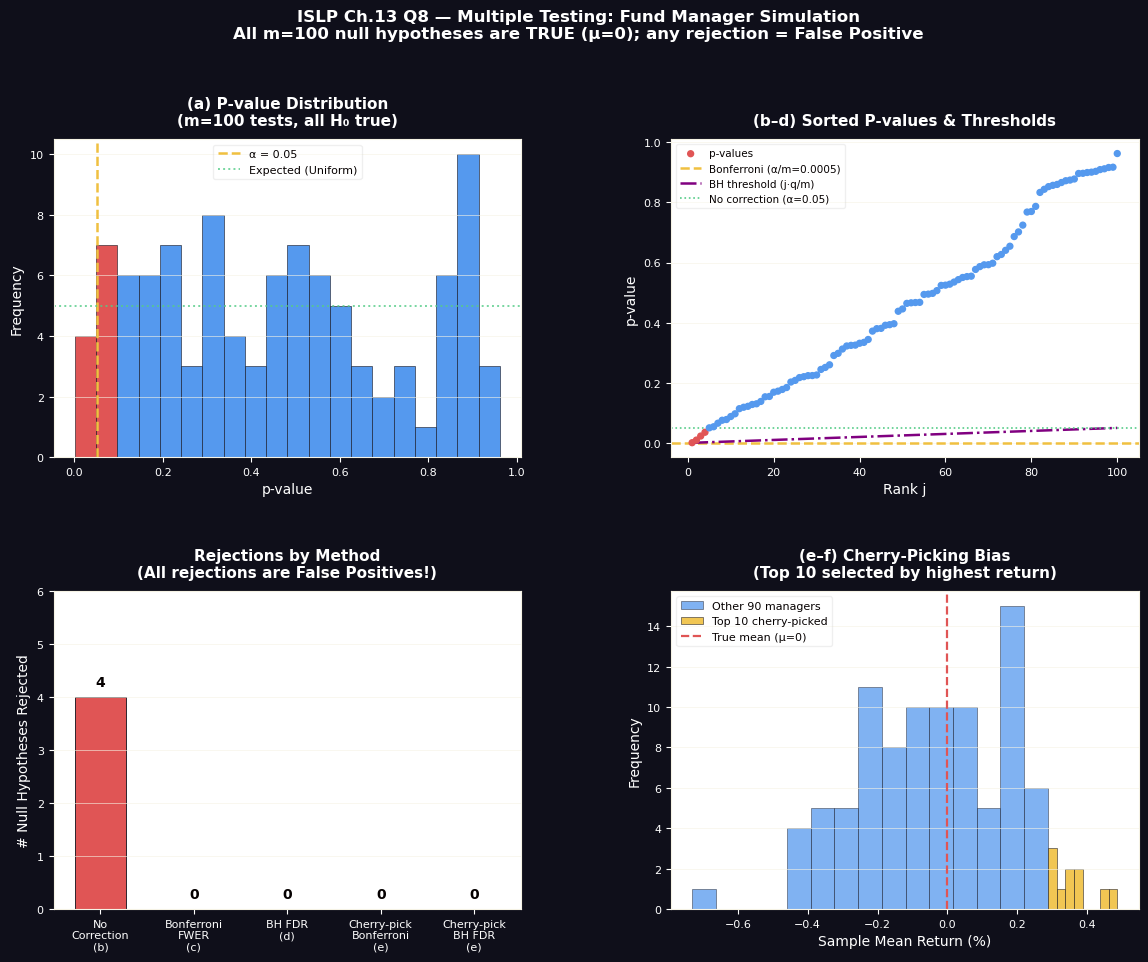

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Setup ─────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(1)
n, m = 20, 100
X = rng.normal(size=(n, m))

# ── Part (a): One-sample t-tests + histogram ───────────────────────────────────
t_stats, p_values = stats.ttest_1samp(X, popmean=0, axis=0)

# ── Parts (b-d): Testing decisions ────────────────────────────────────────────
alpha = 0.05

# (b) No correction
reject_b = p_values < alpha

# (c) Bonferroni FWER
bon_thresh = alpha / m
reject_c   = p_values < bon_thresh

# (d) Benjamini-Hochberg FDR
def bh_fdr(pvals, q):
    m_ = len(pvals)
    order     = np.argsort(pvals)
    sorted_p  = pvals[order]
    thresholds = (np.arange(1, m_+1) / m_) * q
    eligible   = np.where(sorted_p <= thresholds)[0]
    if len(eligible) == 0:
        return np.zeros(m_, dtype=bool)
    k = eligible[-1]
    rejected = np.zeros(m_, dtype=bool)
    rejected[order[:k+1]] = True
    return rejected

reject_d = bh_fdr(p_values, alpha)

# ── Part (e): Cherry-pick top 10 managers ─────────────────────────────────────
top10_idx    = np.argsort(X.mean(axis=0))[-10:]        # best mean returns
p_top10      = p_values[top10_idx]

reject_e_fwer = p_top10 < (alpha / 10)                 # Bonferroni over 10
reject_e_fdr  = bh_fdr(p_top10, alpha)

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 55)
print(" RESULTS SUMMARY")
print("=" * 55)
print(f"\n(a) t-tests conducted on m={m} fund managers (n={n} months)")
print(f"    All null hypotheses TRUE (μ=0 by construction)\n")

print(f"(b) No correction        (α=0.05): {reject_b.sum():>3} rejections")
print(f"    → All {reject_b.sum()} are FALSE POSITIVES (Type I errors)")

print(f"\n(c) Bonferroni FWER      (α=0.05): {reject_c.sum():>3} rejections")
print(f"    Threshold = {alpha}/{m} = {bon_thresh:.4f}")

print(f"\n(d) BH FDR               (q=0.05): {reject_d.sum():>3} rejections")

print(f"\n(e) Cherry-picked top 10 fund managers:")
print(f"    Top-10 mean returns: {X[:,top10_idx].mean(axis=0).round(3)}")
print(f"    Top-10 p-values:     {np.sort(p_top10).round(4)}")
print(f"    Bonferroni FWER (α/10={alpha/10:.3f}): {reject_e_fwer.sum():>3} rejections")
print(f"    BH FDR          (q=0.05):         {reject_e_fdr.sum():>3} rejections")

# ── Plotting ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#0f0f1a')
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

GOLD    = '#f0c040'
RED     = '#e05555'
GREEN   = '#55cc88'
BLUE    = '#5599ee'
PURPLE  = '#800080'
BG      = '#f5f2e4'
PANEL   = '#f5f2e4'
GRID    = '#f5f2e4'
WHITE   = '#ffffff'
LGREY   = '#9090a8'
BLACK   = '#050000'

def style_ax(ax, title):
    ax.set_facecolor(WHITE)
    ax.set_title(title, color=WHITE, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors=WHITE, labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)
    ax.yaxis.label.set_color(WHITE)
    ax.xaxis.label.set_color(WHITE)
    ax.grid(axis='y', color=PANEL, linewidth=0.6, alpha=0.7)

# ── Panel 1: Histogram of all p-values ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts, bins, patches = ax1.hist(p_values, bins=20, edgecolor='#0f0f1a', linewidth=0.4)
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(RED if left < alpha else BLUE)
ax1.axvline(alpha, color=GOLD, linewidth=1.8, linestyle='--', label=f'α = {alpha}')
ax1.axhline(m/20, color=GREEN, linewidth=1.4, linestyle=':', alpha=0.8, label='Expected (Uniform)')
ax1.set_xlabel('p-value')
ax1.set_ylabel('Frequency')
ax1.legend(fontsize=8, framealpha=0.3, labelcolor=BLACK)
style_ax(ax1, f'(a) P-value Distribution\n(m={m} tests, all H₀ true)')

# ── Panel 2: Sorted p-values with thresholds ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sorted_p = np.sort(p_values)
ranks    = np.arange(1, m+1)
bh_line  = ranks * alpha / m

ax2.scatter(ranks, sorted_p,
            c=[RED if p < alpha else BLUE for p in sorted_p],
            s=18, zorder=3, label='p-values')
ax2.axhline(bon_thresh, color=GOLD,   linewidth=1.8, linestyle='--',
            label=f'Bonferroni (α/m={bon_thresh:.4f})')
ax2.plot(ranks, bh_line, color=PURPLE, linewidth=1.8, linestyle='-.',
         label=f'BH threshold (j·q/m)')
ax2.axhline(alpha, color=GREEN, linewidth=1.2, linestyle=':',
            label=f'No correction (α={alpha})')
ax2.set_xlabel('Rank j')
ax2.set_ylabel('p-value')
ax2.legend(fontsize=7.5, framealpha=0.3, labelcolor=BLACK, loc='upper left')
style_ax(ax2, '(b–d) Sorted P-values & Thresholds')

# ── Panel 3: Bar chart of rejections across methods ───────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
methods = ['No\nCorrection\n(b)', 'Bonferroni\nFWER\n(c)', 'BH FDR\n(d)',
           'Cherry-pick\nBonferroni\n(e)', 'Cherry-pick\nBH FDR\n(e)']
counts_ = [reject_b.sum(), reject_c.sum(), reject_d.sum(),
           reject_e_fwer.sum(), reject_e_fdr.sum()]
colors_ = [RED, GREEN, BLUE, PURPLE, GOLD]
bars    = ax3.bar(methods, counts_, color=colors_, edgecolor='#0f0f1a',
                  linewidth=0.6, width=0.55)
for bar, cnt in zip(bars, counts_):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             str(cnt), ha='center', va='bottom', color=BLACK, fontsize=10,
             fontweight='bold')
ax3.set_ylabel('# Null Hypotheses Rejected')
ax3.set_ylim(0, max(counts_) + 2)
ax3.tick_params(axis='x', labelsize=8)
style_ax(ax3, 'Rejections by Method\n(All rejections are False Positives!)')

# ── Panel 4: Cherry-pick illustration ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
all_means   = X.mean(axis=0)
top10_means = all_means[top10_idx]
other_means = np.delete(all_means, top10_idx)

ax4.hist(other_means, bins=15, color=BLUE,   alpha=0.75,
         edgecolor='#0f0f1a', linewidth=0.4, label='Other 90 managers')
ax4.hist(top10_means, bins=8,  color=GOLD,  alpha=0.9,
         edgecolor='#0f0f1a', linewidth=0.4, label='Top 10 cherry-picked')
ax4.axvline(0, color=RED, linewidth=1.6, linestyle='--', label='True mean (μ=0)')
ax4.set_xlabel('Sample Mean Return (%)')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8, framealpha=0.3, labelcolor=BLACK)
style_ax(ax4, '(e–f) Cherry-Picking Bias\n(Top 10 selected by highest return)')

fig.suptitle('ISLP Ch.13 Q8 — Multiple Testing: Fund Manager Simulation\n'
             'All m=100 null hypotheses are TRUE (μ=0); any rejection = False Positive',
             color=WHITE, fontsize=12, fontweight='bold', y=1.01)

plt.savefig('ch13_q8_multiple_testing.png',
            dpi=150, bbox_inches='tight', facecolor=BG)
print("\nPlot saved.")
plt.show()